# Vietnam Statistical Arbitrage: PCA + OU Mean Reversion
## Baseline Notebook (Long-Only + VN30 Futures Hedge)

This notebook implements a statistical arbitrage strategy for Vietnam stocks:
- **Factor Model**: Rolling PCA on stock returns
- **Signal**: OU/AR(1) mean-reversion fitted to residuals
- **Portfolio**: Long-only, equal-weight, VN30-hedged
- **Goal**: Validate the research pipeline before optimization

Pipeline:
1. Data loading & preprocessing
2. Universe definition
3. Rolling PCA factor extraction
4. Residual construction
5. OU/AR(1) mean-reversion fitting
6. S-score signal generation
7. Long-only signal logic
8. Equal-weight portfolio construction
9. VN30 futures hedge computation
10. Backtest engine
11. Performance analysis & diagnostics

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')
print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')

Libraries loaded successfully.
Pandas: 3.0.1
NumPy: 2.4.3


# SECTION 1: Data Loading and Preprocessing
## Vietnam stocks + VN30 futures prices, volumes, and returns

In [12]:
## Define date range
START_DATE = '2018-01-02'
END_DATE   = '2025-12-31'

print(f'Analysis period: {START_DATE} to {END_DATE}\n')

## Load Vietnam stock prices
stock_price_df = pd.read_csv('vietnam_stock_price_full.csv', index_col=0, parse_dates=True)
print(f'Stock price shape: {stock_price_df.shape}')
print(f'Stock price date range: {stock_price_df.index.min().date()} to {stock_price_df.index.max().date()}')
print(f'Stock price missing (total): {stock_price_df.isna().sum().sum()}\n')

## Load Vietnam stock volumes
stock_volume_df = pd.read_csv('vietnam_stock_volume_full.csv', index_col=0, parse_dates=True)
print(f'Stock volume shape: {stock_volume_df.shape}')
print(f'Stock volume date range: {stock_volume_df.index.min().date()} to {stock_volume_df.index.max().date()}\n')

## Load VN30 futures prices
fu_vn30_df = pd.read_csv('FU_VN30_full.csv', index_col=0, parse_dates=True)
print(f'VN30 futures shape: {fu_vn30_df.shape}')
print(f'VN30 futures date range: {fu_vn30_df.index.min().date()} to {fu_vn30_df.index.max().date()}\n')

Analysis period: 2018-01-02 to 2025-12-31

Stock price shape: (2872, 702)
Stock price date range: 2014-07-09 to 2025-12-31
Stock price missing (total): 248600

Stock volume shape: (2872, 702)
Stock volume date range: 2014-07-09 to 2025-12-31

VN30 futures shape: (2141, 5)
VN30 futures date range: 2017-08-10 to 2026-03-11



In [13]:
# =========================
# FIX 2: clean stock data without creating fake tradability
# =========================
missing_pct = stock_price_df.isna().mean() * 100
stocks_to_keep = missing_pct[missing_pct <= 5].index

print(f"Removing {len(stock_price_df.columns) - len(stocks_to_keep)} stocks with >5% missing data")
print(f"Keeping {len(stocks_to_keep)} stocks initially")

stock_price_clean = stock_price_df[stocks_to_keep].copy()
stock_volume_clean = stock_volume_df[stocks_to_keep].copy()

# Do NOT forward-fill prices or volume for trading logic

valid_ratio = stock_price_clean.notna().mean()
stocks_final = valid_ratio[valid_ratio >= 0.95].index

stock_price_clean = stock_price_clean[stocks_final].copy()
stock_volume_clean = stock_volume_clean[stocks_final].copy()

print(f"After secondary filter: {len(stocks_final)} stocks")
print(f"Price shape: {stock_price_clean.shape}")
print(f"Volume shape: {stock_volume_clean.shape}")

# =========================
# FIX 1: choose VN30 futures close explicitly
# =========================
if isinstance(fu_vn30_df, pd.DataFrame):
    lower_map = {str(c).lower(): c for c in fu_vn30_df.columns}

    if 'close' in lower_map:
        vn30_price_aligned = fu_vn30_df[lower_map['close']].copy()
    elif 'settlement price' in lower_map:
        vn30_price_aligned = fu_vn30_df[lower_map['settlement price']].copy()
    else:
        raise ValueError(
            f"Cannot identify futures close column. Available columns: {list(fu_vn30_df.columns)}"
        )
else:
    vn30_price_aligned = fu_vn30_df.copy()

vn30_price_aligned.name = 'VN30_FUT_CLOSE'
print("Using VN30 futures series:", vn30_price_aligned.name)

# =========================
# FIX 3: align dates and build tradability mask
# =========================
common_dates = (
    stock_price_clean.index
    .intersection(stock_volume_clean.index)
    .intersection(vn30_price_aligned.index)
)

stock_price = stock_price_clean.loc[common_dates].copy()
stock_volume = stock_volume_clean.loc[common_dates].copy()
vn30_price = vn30_price_aligned.loc[common_dates].copy()

tradable_mask = (
    stock_price.notna() &
    stock_volume.notna() &
    (stock_volume > 0)
)

print("Aligned stock price shape:", stock_price.shape)
print("Aligned stock volume shape:", stock_volume.shape)
print("Aligned VN30 futures shape:", vn30_price.shape)
print("Tradable entries:", tradable_mask.sum().sum())

Removing 276 stocks with >5% missing data
Keeping 426 stocks initially
After secondary filter: 426 stocks
Price shape: (2872, 426)
Volume shape: (2872, 426)
Using VN30 futures series: VN30_FUT_CLOSE
Aligned stock price shape: (2098, 426)
Aligned stock volume shape: (2098, 426)
Aligned VN30 futures shape: (2098,)
Tradable entries: 769288


In [14]:
# =========================
# FIX 5: compute returns only where both days are tradable
# =========================
stock_returns_raw = stock_price.pct_change()
vn30_returns = vn30_price.pct_change()

tradable_return_mask = tradable_mask & tradable_mask.shift(1)

stock_returns = stock_returns_raw.where(tradable_return_mask)
stock_returns = stock_returns.dropna(how='all')

vn30_returns = vn30_returns.dropna()

common_dates = stock_returns.index.intersection(vn30_returns.index)

stock_returns = stock_returns.loc[common_dates]
vn30_returns = vn30_returns.loc[common_dates]
stock_price = stock_price.loc[common_dates]
stock_volume = stock_volume.loc[common_dates]
tradable_mask = tradable_mask.loc[common_dates]

print("Stock returns shape:", stock_returns.shape)
print("VN30 returns shape:", vn30_returns.shape)

## Summary statistics
print('Stock returns summary:')
print(f'  Mean: {stock_returns.mean().mean():.6f}')
print(f'  Std:  {stock_returns.std().mean():.6f}')
print(f'  Min:  {stock_returns.min().min():.6f}')
print(f'  Max:  {stock_returns.max().max():.6f}\n')

print('VN30 returns summary:')
print(f'  Mean: {vn30_returns.mean():.6f}')
print(f'  Std:  {vn30_returns.std():.6f}')
print(f'  Min:  {vn30_returns.min():.6f}')
print(f'  Max:  {vn30_returns.max():.6f}')

Stock returns shape: (2097, 426)
VN30 returns shape: (2097,)
Stock returns summary:
  Mean: inf
  Std:  0.031406
  Min:  -1.000000
  Max:  inf

VN30 returns summary:
  Mean: 0.000589
  Std:  0.014873
  Min:  -0.110069
  Max:  0.069971


# SECTION 2: Universe Definition
## Define trading universe based on liquidity filters
Universe logic: select top N stocks by average volume over a rolling window

In [15]:
def select_liquid_universe(price_df, volume_df, date, top_n=300, lookback_window=366):
    """
    Select top N stocks by liquidity on a given date.
    
    Args:
        price_df: DataFrame of stock prices
        volume_df: DataFrame of stock volumes
        date: Trading date
        top_n: Number of top liquid stocks to select
        lookback_window: Days to look back for liquidity calculation
        
    Returns:
        price_window: Clean price data for selected stocks
        volume_window: Clean volume data for selected stocks
    """
    # Filter stocks with price data available on the given date
    stocks_available = price_df.loc[date].notna()
    
    # Get lookback window
    window_start = date - pd.Timedelta(days=lookback_window)
    price_window = price_df.loc[window_start:date, stocks_available].copy()
    volume_window = volume_df.loc[window_start:date, stocks_available].copy()
    
    # Calculate average volume (most recent day)
    latest_volume = volume_window.iloc[-1]  # Most recent volume
    top_stocks = latest_volume.nlargest(top_n).index.tolist()
    
    # Clean: forward-fill, drop rows with any missing in final selection
    price_window = price_window[top_stocks].ffill(limit=2)
    price_window = price_window.dropna(axis=1, how='any')
    
    final_stocks = price_window.columns
    volume_window = volume_window[final_stocks].ffill(limit=5)
    
    return price_window, volume_window

## Test universe selection on a recent date
test_date = stock_price.index[-100]  # 100 days before end
test_price, test_volume = select_liquid_universe(stock_price, stock_volume, test_date, top_n=100)
print(f'Universe selection test (date={test_date.date()}):')
print(f'  Selected {len(test_price.columns)} liquid stocks')
print(f'  Price data shape: {test_price.shape}')
print(f'  Volume data shape: {test_volume.shape}')

Universe selection test (date=2025-08-12):
  Selected 100 liquid stocks
  Price data shape: (250, 100)
  Volume data shape: (250, 100)


# SECTION 3: Rolling PCA Factor Extraction
## Compute PCA factors on rolling estimation window
Strategy: standardize returns, compute empirical correlation, perform eigendecomposition

In [16]:
def standardize_returns(ret_window):
    """
    Standardize returns: Y_ik = (R_ik - mean_i) / std_i per stock
    """
    mean_per_stock = ret_window.mean(axis=0)
    std_per_stock = ret_window.std(axis=0, ddof=1).replace(0, np.nan)
    Y = (ret_window - mean_per_stock) / std_per_stock
    return Y.dropna(axis=1)  # drop any stock with zero std

def compute_correlation_matrix(Y):
    """
    Compute empirical correlation from standardized returns
    """
    M = Y.shape[0]  # number of observations
    return (Y.values.T @ Y.values) / (M - 1)

def eigen_decomposition_sorted(corr_matrix):
    """
    Eigendecomposition with eigenvalues sorted descending
    """
    eigvals, eigvecs = np.linalg.eigh(corr_matrix)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

# =========================
# FIX 6: robust rolling PCA
# =========================
def rolling_pca(returns, estimation_window=252, n_factors=5, min_stocks=20):
    dates = returns.index
    pca_dict = {}

    for t in range(estimation_window, len(dates)):
        trading_date = dates[t]

        est_start = t - estimation_window
        est_end = t
        ret_window = returns.iloc[est_start:est_end].copy()

        ret_window = ret_window.dropna(axis=1, how='any')
        if ret_window.shape[1] < min_stocks:
            continue

        mean_per_stock = ret_window.mean(axis=0)
        std_per_stock = ret_window.std(axis=0, ddof=1)

        valid_cols = std_per_stock[std_per_stock > 1e-12].index
        ret_window = ret_window[valid_cols]
        mean_per_stock = mean_per_stock[valid_cols]
        std_per_stock = std_per_stock[valid_cols]

        if ret_window.shape[1] < min_stocks:
            continue

        Y = (ret_window - mean_per_stock) / std_per_stock
        corr = np.corrcoef(Y.values.T)

        eigvals, eigvecs = np.linalg.eigh(corr)
        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]

        k = min(n_factors, ret_window.shape[1] - 1)
        if k < 1:
            continue

        V = eigvecs[:, :k]
        Q = V / std_per_stock.values.reshape(-1, 1)

        pca_dict[trading_date] = {
            'Q': Q,
            'stocks': ret_window.columns.tolist(),
            'k': k,
            'eigvals': eigvals[:k],
        }

    return pca_dict

## Run rolling PCA
print("Running rolling PCA...")
pca_results = rolling_pca(stock_returns, estimation_window=252, n_factors=5, min_stocks=20)
print(f"PCA available for {len(pca_results)} dates")

Running rolling PCA...
PCA available for 1845 dates


# SECTION 4: Residual Construction
## Use PCA factors to compute fitted & residual returns

In [17]:
# =========================
# FIX 7: correct residual regression
# =========================
def compute_residuals(returns, pca_dict, regression_window=60, min_obs=40):
    dates = returns.index
    residuals = pd.DataFrame(index=dates, columns=returns.columns, dtype=float)

    for trading_date in sorted(pca_dict.keys()):
        if trading_date not in dates:
            continue

        t = dates.get_loc(trading_date)
        if t < regression_window:
            continue

        pca_info = pca_dict[trading_date]
        Q = pca_info['Q']
        stocks = pca_info['stocks']

        reg_start = t - regression_window
        reg_end = t
        R_reg_df = returns.iloc[reg_start:reg_end][stocks].copy()

        valid_rows = R_reg_df.notna().all(axis=1)
        R_reg_df = R_reg_df.loc[valid_rows]

        if R_reg_df.shape[0] < min_obs:
            continue

        R_reg = R_reg_df.values
        F_reg = R_reg @ Q

        X = np.column_stack([np.ones(R_reg.shape[0]), F_reg])

        r_today = returns.loc[trading_date, stocks]
        if r_today.isna().any():
            continue

        r_today = r_today.values
        f_today = r_today @ Q
        x_today = np.concatenate([[1.0], f_today])

        try:
            beta_all = np.linalg.lstsq(X, R_reg, rcond=None)[0]
        except np.linalg.LinAlgError:
            continue

        fitted_ret = x_today @ beta_all

        for i, stock in enumerate(stocks):
            residuals.loc[trading_date, stock] = r_today[i] - fitted_ret[i]

    return residuals

print("Computing residuals...")
residuals = compute_residuals(stock_returns, pca_results, regression_window=60, min_obs=40)
print("Residuals shape:", residuals.shape)
print("Residual missing:", residuals.isna().sum().sum())

Computing residuals...
Residuals shape: (2097, 426)
Residual missing: 574819


# SECTION 5: OU/AR(1) Mean Reversion Fitting
## Fit Ornstein-Uhlenbeck model to residuals to estimate mean-reversion parameters

In [18]:
# =========================
# FIX 8: robust OU fitting
# =========================
def fit_ou_model(residuals, window=60, limit=False, kappa_min=8.4, min_obs=40):
    kappa = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    mu = kappa.copy()
    sigma_eq = kappa.copy()

    for col in residuals.columns:
        series = residuals[col]

        for t in range(window, len(series)):
            eps_win = series.iloc[t - window:t].dropna()

            if len(eps_win) < min_obs:
                continue

            Xcum = eps_win.cumsum().values
            if len(Xcum) < 3:
                continue

            x_prev = Xcum[:-1]
            x_next = Xcum[1:]

            A = np.column_stack([np.ones(len(x_prev)), x_prev])

            try:
                a, b = np.linalg.lstsq(A, x_next, rcond=None)[0]
            except np.linalg.LinAlgError:
                continue

            resid_ar = x_next - (a + b * x_prev)
            var_xi = np.var(resid_ar, ddof=1)

            if not np.isfinite(b) or not np.isfinite(var_xi):
                continue
            if var_xi <= 1e-12:
                continue
            if b <= 0 or b >= 0.9672:
                continue

            kappa_val = -np.log(b) * 252.0
            mu_val = a / (1.0 - b)
            sigma_eq_val = np.sqrt(var_xi / (1.0 - b**2))

            if not np.isfinite(kappa_val) or not np.isfinite(mu_val) or not np.isfinite(sigma_eq_val):
                continue
            if sigma_eq_val <= 1e-12:
                continue
            if limit and kappa_val < kappa_min:
                continue

            date = series.index[t]
            kappa.loc[date, col] = kappa_val
            mu.loc[date, col] = mu_val
            sigma_eq.loc[date, col] = sigma_eq_val

    return kappa, mu, sigma_eq

## Fit OU model (without kappa filter first)
print('Fitting OU model to residuals (limit=False)...')
kappa_df, mu_df, sigma_eq_df = fit_ou_model(residuals=residuals, window=60, limit=False, kappa_min=8.4)
print(f'OU parameters created')
print(f'Kappa median: {kappa_df.stack().median():.2f} (annualized)')
print(f'Sigma_eq median: {sigma_eq_df.stack().median():.6f}')

Fitting OU model to residuals (limit=False)...
OU parameters created
Kappa median: 30.01 (annualized)
Sigma_eq median: 0.038602


In [19]:
## Create focused OU parameter summary dataframe
print('\nCreating focused OU parameter summary...')

ou_stats_list = []
kappa_min = 8.4  # From paper's filtering logic

for stock in kappa_df.columns:
    kappa_vals = kappa_df[stock].dropna()
    mu_vals = mu_df[stock].dropna()
    sigma_eq_vals = sigma_eq_df[stock].dropna()
    
    if len(kappa_vals) == 0:
        continue
    
    # Calculate derived metrics
    kappa_median = kappa_vals.median()
    kappa_q1 = kappa_vals.quantile(0.25)
    kappa_q3 = kappa_vals.quantile(0.75)
    kappa_iqr = kappa_q3 - kappa_q1
    
    # Half-life in days (ln(2) / kappa, where kappa is annualized)
    halflife_median = np.log(2) / kappa_median if kappa_median > 0 else np.nan
    
    # Pass rate: percentage of kappa values >= kappa_min threshold
    pass_rate_kappa = (kappa_vals >= kappa_min).sum() / len(kappa_vals) * 100
    
    row = {
        'Stock': stock,
        'Valid_OU_Fits': len(kappa_vals),
        'Kappa_Median': kappa_median,
        'Kappa_IQR': kappa_iqr,
        'HalfLife_Median': halflife_median,
        'PassRate_Kappa': pass_rate_kappa,
        'SigmaEq_Median': sigma_eq_vals.median(),
        'AbsMu_Median': abs(mu_vals.median()),
    }
    ou_stats_list.append(row)

ou_stats_df = pd.DataFrame(ou_stats_list).set_index('Stock')
ou_stats_df


Creating focused OU parameter summary...


,Valid_OU_Fits,Kappa_Median,Kappa_IQR,HalfLife_Median,PassRate_Kappa,SigmaEq_Median,AbsMu_Median
Stock,,,,,,,
WSS,87,27.112591,23.192624,0.025566,100.0,0.047238,0.068561
VTV,377,51.790575,62.072611,0.013384,100.0,0.034905,0.024229
VTO,1263,32.417026,28.643402,0.021382,100.0,0.034363,0.002513
VSH,1004,31.350824,31.787647,0.022109,100.0,0.024687,0.008915
VSC,1307,23.738733,21.157637,0.029199,100.0,0.043590,0.010856
...,...,...,...,...,...,...,...
ACL,1375,33.186058,32.298972,0.020887,100.0,0.039935,0.013783
ACC,796,28.055858,29.678667,0.024706,100.0,0.030578,0.018905
ACB,1376,29.637581,29.391344,0.023387,100.0,0.020747,0.007390


### Định nghĩa các cột dữ liệu (Column Definitions)
- Valid_OU_Fits (Độ bao phủ khớp lệnh): 

Số lượng các lần khớp tham số OU hợp lệ cho mỗi mã cổ phiếu (thể hiện tính đầy đủ của dữ liệu).
- Kappa_Median (Tốc độ hồi quy trung vị): 

Giá trị trung vị của tốc độ hồi quy về mức trung bình (mean-reversion speed) đã được quy năm.
- Kappa_IQR (Độ ổn định tham số): 

Khoảng cách giữa các tứ phân vị (Q3 - Q1), dùng để đo lường độ ổn định của tham số Kappa.
- HalfLife_Median (Thời gian bán rã trung vị): 

Thời gian trung vị tính bằng ngày để mức thặng dư giảm đi một nửa, tính theo công thức: ln(2) / Kappa\_Median.
- PassRate_Kappa (Tỷ lệ vượt ngưỡng Kappa): 

Tỷ lệ phần trăm (%) các quan sát có Kappa $\geq$ 8.4 (phù hợp với logic lọc tín hiệu của bài báo gốc).
- SigmaEq_Median (Biến động cân bằng trung vị): 

Giá trị trung vị của độ biến động tại trạng thái cân bằng (hỗ trợ việc chuẩn hóa/thang đo tín hiệu).
- AbsMu_Median (Độ lệch cân bằng tuyệt đối trung vị): 

Giá trị trung vị của trị tuyệt đối độ lệch trạng thái cân bằng (dùng để tránh việc triệt tiêu dấu khi tính toán độ lệch tổng thể).


In [20]:
## Create OU parameter summary dataframe (stocks as rows, statistics as columns)
print('\nCreating OU parameter summary...')

ou_summary_list = []

for stock in kappa_df.columns:
    kappa_vals = kappa_df[stock].dropna()
    mu_vals = mu_df[stock].dropna()
    sigma_eq_vals = sigma_eq_df[stock].dropna()
    
    row = {
        'Stock': stock,
        'Kappa_Median': kappa_vals.median(),
        'Kappa_Std': kappa_vals.std(),
        'Mu_Median': mu_vals.median(),
        'Mu_Std': mu_vals.std(),
        'Sigma_Eq_Median': sigma_eq_vals.median(),
        'Sigma_Eq_Std': sigma_eq_vals.std(),
        'Observations': len(kappa_vals),
    }
    ou_summary_list.append(row)

ou_summary_df = pd.DataFrame(ou_summary_list).set_index('Stock')

ou_summary_df


Creating OU parameter summary...


,Kappa_Median,Kappa_Std,Mu_Median,Mu_Std,Sigma_Eq_Median,Sigma_Eq_Std,Observations
Stock,,,,,,,
WSS,27.112591,21.653905,-0.068561,0.044598,0.047238,0.013285,87
WCS,NaN,NaN,NaN,NaN,NaN,NaN,0
VTV,51.790575,68.065141,0.024229,0.057226,0.034905,0.016099,377
VTO,32.417026,26.052101,-0.002513,0.079146,0.034363,0.018361,1263
VTC,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...
ACC,28.055858,29.747583,-0.018905,0.120905,0.030578,0.025179,796
ACB,29.637581,25.842574,0.007390,0.046652,0.020747,0.010702,1376
ABT,NaN,NaN,NaN,NaN,NaN,NaN,0


# SECTION 6: S-Score Signal Generation
## Compute standardized signal from residuals and OU parameters

In [21]:
# =========================
# FIX 9: stable s-score computation
# =========================
def compute_s_score(residuals, mu, sigma_eq, window=60, min_obs=40):
    s = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)

    for col in residuals.columns:
        eps = residuals[col]

        for t in range(window, len(eps)):
            eps_win = eps.iloc[t - window:t].dropna()
            if len(eps_win) < min_obs:
                continue

            x_t = eps_win.cumsum().iloc[-1]
            mu_t = mu.iloc[t, mu.columns.get_loc(col)]
            sigma_t = sigma_eq.iloc[t, sigma_eq.columns.get_loc(col)]

            if pd.isna(mu_t) or pd.isna(sigma_t) or sigma_t <= 1e-12:
                continue

            s.iloc[t, s.columns.get_loc(col)] = (x_t - mu_t) / sigma_t

    return s

## Compute s-scores
print('Computing s-scores...')
sscore_df = compute_s_score(residuals, mu_df, sigma_eq_df, window=60)
print(f'S-score shape: {sscore_df.shape}')
print(f'S-score median: {sscore_df.stack().median():.4f}')
print(f'S-score std: {sscore_df.stack().std():.4f}')

Computing s-scores...
S-score shape: (2097, 426)
S-score median: -0.0560
S-score std: 0.9386


In [22]:
sscore_df

,WSS,WCS,VTV,VTO,VTC,VTB,VSI,VSH,VSC,VRC,...,ALT,AGR,ADP,ADC,ACL,ACC,ACB,ABT,AAM,AAA
2017-08-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,NaN,NaN,-0.459781,-0.526722,NaN,NaN,NaN,0.401086,0.645899,NaN,...,NaN,1.204960,NaN,NaN,0.888402,NaN,-0.898999,NaN,NaN,-0.949254
2025-12-26,NaN,NaN,0.072503,-0.317045,NaN,NaN,NaN,0.212457,0.783108,NaN,...,NaN,1.128394,NaN,NaN,0.654181,NaN,-1.237826,NaN,NaN,-0.975256
2025-12-29,NaN,NaN,0.807549,-0.428732,NaN,NaN,NaN,0.306371,0.357030,NaN,...,NaN,1.074799,NaN,NaN,0.629279,NaN,-1.300732,NaN,NaN,-1.176319
2025-12-30,NaN,NaN,0.577072,-0.939021,NaN,NaN,NaN,1.049724,0.496991,NaN,...,NaN,1.010433,NaN,NaN,0.138819,NaN,-1.102380,NaN,NaN,-1.375132


# SECTION 7: Long-Only Signal Logic
## Generate long-only trading signals based on s-score thresholds

Trading rules (long-only baseline):
- Open long: when s-score falls below -threshold (stock oversold/undervalued)
- Close long: when s-score rises above -close_threshold (mean-reversion towards equilibrium)

In [23]:
# =========================
# FIX 10: long-only signals with dynamic percentile-based thresholds
# =========================
def generate_signals_long_only(s_df, tradable_mask=None, percentile_window=60, entry_pct=5, exit_pct=95):
    """
    Generate long-only signals using dynamic percentile-based thresholds.
    
    For each stock on each day:
    - Calculate entry_threshold as the entry_pct percentile of s-scores over the past percentile_window days
    - Calculate exit_threshold as the exit_pct percentile of s-scores over the past percentile_window days
    - Go long when s-score < entry_threshold (extreme low = oversold)
    - Close long when s-score > exit_threshold (recovery/mean reversion)
    
    Args:
        s_df: DataFrame of s-scores (index=dates, columns=stocks)
        tradable_mask: DataFrame of tradability (same shape as s_df)
        percentile_window: Rolling window in days for percentile calculation (default 60)
        entry_pct: Entry percentile threshold (default 5, meaning 5th percentile)
        exit_pct: Exit percentile threshold (default 95, meaning 95th percentile)
    
    Returns:
        signals: DataFrame of signals (0=flat, 1=long)
    """
    signals = pd.DataFrame(0, index=s_df.index, columns=s_df.columns, dtype=int)
    current = pd.Series(0, index=s_df.columns, dtype=int)

    for t in range(percentile_window, len(s_df.index)):
        date = s_df.index[t]
        prev_date = s_df.index[t - 1]

        s_prev = s_df.loc[prev_date]

        if tradable_mask is not None:
            tradable_today = tradable_mask.loc[date].reindex(s_df.columns).fillna(False)
        else:
            tradable_today = pd.Series(True, index=s_df.columns)

        # Get rolling window for percentile calculation
        window_start = t - percentile_window
        window_end = t
        s_window = s_df.iloc[window_start:window_end]

        for stock in s_df.columns:
            val = s_prev[stock]

            if pd.isna(val) or (not tradable_today[stock]):
                current[stock] = 0
                continue

            # Get stock's s-scores over the lookback window
            stock_window = s_window[stock].dropna()

            if len(stock_window) < max(10, percentile_window // 2):
                # Not enough data for reliable percentile calculation
                current[stock] = 0
                continue

            # Calculate dynamic thresholds for this stock on this day
            entry_threshold = stock_window.quantile(entry_pct / 100.0)
            exit_threshold = stock_window.quantile(exit_pct / 100.0)

            # Signal logic: mean reversion trading with dynamic thresholds
            if current[stock] == 0:
                # Flat position: go long when s-score hits extreme low (entry threshold)
                if val < entry_threshold:
                    current[stock] = 1
            else:
                # In long position: close when s-score recovers to exit level
                if val > exit_threshold:
                    current[stock] = 0

        signals.loc[date] = current.values

    return signals

## Generate signals with dynamic percentile thresholds
print('Generating long-only signals with dynamic percentile-based thresholds...')
signals_df = generate_signals_long_only(sscore_df, tradable_mask=tradable_mask, 
                                        percentile_window=60, entry_pct=5, exit_pct=95)
print(f'Signals shape: {signals_df.shape}')
total_long_signal_days = (signals_df == 1).sum().sum()
print(f'Total long signal-days: {total_long_signal_days}')
print(f'Avg positions per day: {(signals_df == 1).sum().mean():.2f}')

Generating long-only signals with dynamic percentile-based thresholds...
Signals shape: (2097, 426)
Total long signal-days: 107164
Avg positions per day: 251.56


In [24]:
signals_df

,WSS,WCS,VTV,VTO,VTC,VTB,VSI,VSH,VSC,VRC,...,ALT,AGR,ADP,ADC,ACL,ACC,ACB,ABT,AAM,AAA
2017-08-11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-08-14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-08-15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-08-16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-08-17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
2025-12-26,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
2025-12-29,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
2025-12-30,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


# SECTION 8: Equal-Weight Portfolio Construction
## Build equal-weight long-only portfolio from signals

Portfolio rules:
- Equal weight across all active long positions on each date
- No leverage, no optimization
- Simple and transparent construction

In [25]:
# =========================
# PORTFOLIO WEIGHTING MODULE (MODULAR, 4 METHODS)
# =========================
# Easy-to-swap weighting functions for long-only contrarian stat-arb strategy
# Each method returns normalized weights (sum=1) across active stocks

def weight_equal(s_scores, active_mask):
    """
    METHOD 1: EQUAL WEIGHT
    Every active stock gets identical weight.
    
    Parameters
    ----------
    s_scores : pd.Series
        S-scores (not used in this method)
    active_mask : pd.Series
        Boolean Series, True = active long position
    
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    """
    raw = pd.Series(1.0, index=active_mask.index)
    raw[~active_mask] = 0.0
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_linear_distance(s_scores, active_mask, q_open):
    """
    METHOD 2: LINEAR DISTANCE WEIGHTING
    Weight proportional to signal distance beyond opening threshold.
    
    Distance formula (for contrarian strategy):
        d_i = max(0, q_open - s_i)
    
    where:
    - q_open is the opening threshold (typically left-tail quantile, e.g., 5th percentile)
    - s_i is the s-score (more negative = stronger signal)
    - This measures "how far into the long territory" the stock is
    
    Parameters
    ----------
    s_scores : pd.Series
        Standardized s-scores by ticker
    active_mask : pd.Series
        Boolean Series, True = active long position
    q_open : float
        Opening threshold (e.g., 5th percentile or -1.56)
    
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    
    Examples
    --------
    q_open = -1.56
    s = pd.Series({'A': -1.30, 'B': -1.60, 'C': -2.10})
    active = pd.Series({'A': True, 'B': True, 'C': True})
    
    Distance: d_A = 0.00, d_B = 0.04, d_C = 0.54
    Weights after normalization: 0, 0.069, 0.931
    """
    if q_open is None:
        raise ValueError("weight_linear_distance requires q_open parameter")
    
    # Compute distance: d_i = max(0, q_open - s_i)
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Apply active mask: inactive stocks get zero
    raw = distance.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_capped_linear_distance(s_scores, active_mask, q_open, signal_cap=0.75):
    """
    METHOD 3: CAPPED LINEAR DISTANCE WEIGHTING
    Linear distance weighting with a cap to reduce extreme concentration.
    
    Distance: d_i = max(0, q_open - s_i)
    Raw score: a_i = min(d_i, signal_cap) for active, 0 for inactive
    
    Purpose: preserve signal ordering while limiting excessive concentration from outliers
    
    Parameters
    ----------
    s_scores : pd.Series
        Standardized s-scores by ticker
    active_mask : pd.Series
        Boolean Series, True = active long position
    q_open : float
        Opening threshold
    signal_cap : float, default 0.75
        Maximum raw score before normalization
    
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    """
    if q_open is None:
        raise ValueError("weight_capped_linear_distance requires q_open parameter")
    
    # Compute distance
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Cap the distance
    capped = np.minimum(distance, signal_cap)
    
    # Apply active mask
    raw = capped.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_ou_expected_return(s_scores, active_mask, q_open, kappa, sigma_eq=None):
    """
    METHOD 4: OU-BASED EXPECTED RETURN WEIGHTING
    Weight by distance scaled by OU mean-reversion quality.
    
    Core formula:
        d_i = max(0, q_open - s_i)
        a_i = kappa_i * d_i
    
    Optional variant (if sigma_eq provided):
        a_i = kappa_i * d_i / sigma_eq_i
    
    Intuition: stocks with higher mean-reversion speed (kappa) should get more weight
    for the same signal strength. Higher kappa = faster reversion to mean.
    
    Parameters
    ----------
    s_scores : pd.Series
        Standardized s-scores by ticker
    active_mask : pd.Series
        Boolean Series, True = active long position
    q_open : float
        Opening threshold
    kappa : pd.Series
        OU mean-reversion speed by ticker (>0 preferred)
        If missing or nonpositive, that ticker gets zero weight
    sigma_eq : pd.Series, optional
        Equilibrium volatility by ticker
        If provided, divides the raw score (risk adjustment)
    
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    """
    if q_open is None:
        raise ValueError("weight_ou_expected_return requires q_open parameter")
    if kappa is None:
        raise ValueError("weight_ou_expected_return requires kappa parameter")
    
    # Ensure kappa is aligned to s_scores index
    kappa = kappa.reindex(s_scores.index).fillna(0.0)
    
    # Compute distance
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Scale by kappa: filter out nonpositive kappa (no mean reversion)
    scaled_distance = distance.copy()
    scaled_distance[kappa <= 0.0] = 0.0  # No weight if kappa invalid
    scaled_distance[kappa > 0.0] = scaled_distance[kappa > 0.0] * kappa[kappa > 0.0]
    
    # Optional volatility adjustment
    if sigma_eq is not None:
        sigma_eq = sigma_eq.reindex(s_scores.index).fillna(1e-6)
        sigma_eq = np.maximum(sigma_eq, 1e-6)  # Prevent division by zero
        scaled_distance = scaled_distance / sigma_eq
    
    # Apply active mask
    raw = scaled_distance.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def apply_weight_cap(weights, max_weight):
    """
    HELPER: Apply per-stock weight cap with proportional redistribution.
    
    Caps each weight at max_weight, then redistributes excess to uncapped positions.
    Repeat until feasible or max iterations reached.
    
    Parameters
    ----------
    weights : pd.Series
        Portfolio weights (should sum to ~1.0)
    max_weight : float or None
        Maximum weight per position. If None or >= 1.0, returns unchanged.
    
    Returns
    -------
    pd.Series
        Capped weights (normalized to sum = 1.0 if possible)
    """
    if max_weight is None or max_weight >= 1.0:
        return weights
    
    w = weights.copy()
    max_iters = 10
    
    for _ in range(max_iters):
        # Cap all weights
        excess = (w - max_weight).clip(lower=0.0).sum()
        w = w.clip(upper=max_weight)
        
        if excess < 1e-12:
            break
        
        # Redistribute to uncapped
        uncapped_mask = w < max_weight - 1e-12
        uncapped_sum = w[uncapped_mask].sum()
        
        if uncapped_sum < 1e-12:
            break  # No room to redistribute
        
        redistribution = excess * (w[uncapped_mask] + 1e-12) / (uncapped_sum + 1e-12)
        w[uncapped_mask] += redistribution
    
    # Final normalization
    total = w.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=weights.index)
    return w / total


def compute_portfolio_weights(
    s_scores,
    active_mask,
    method="equal",
    q_open=None,
    signal_cap=0.75,
    kappa=None,
    sigma_eq=None,
    max_weight=None
):
    """
    WRAPPER: Main dispatcher for portfolio weighting methods.
    
    Selects one of 4 weighting methods and returns normalized weights.
    
    Parameters
    ----------
    s_scores : pd.Series
        S-scores indexed by ticker
    active_mask : pd.Series
        Boolean mask (True = active long position)
    method : str, default "equal"
        Method choice: "equal", "linear", "capped_linear", "ou"
    q_open : float, optional
        Signal threshold (required for linear, capped_linear, ou methods)
    signal_cap : float, default 0.75
        Cap for capped_linear method
    kappa : pd.Series, optional
        OU mean-reversion speed (required for ou method)
    sigma_eq : pd.Series, optional
        Equilibrium volatility (optional for ou method)
    max_weight : float, optional
        Final per-stock weight cap
    
    Returns
    -------
    pd.Series
        Normalized weights (sum=1), indexed by ticker
    
    Raises
    ------
    ValueError
        If method is unknown or required parameters are missing
    
    Examples
    --------
    # Toy data
    s_scores = pd.Series([-1.5, -0.8, -2.1], index=['A', 'B', 'C'])
    active = pd.Series([True, True, True], index=['A', 'B', 'C'])
    
    # Equal weight
    w1 = compute_portfolio_weights(s_scores, active, method="equal")
    # Result: A=0.333, B=0.333, C=0.333
    
    # Linear distance (q_open = -1.56)
    w2 = compute_portfolio_weights(s_scores, active, method="linear", q_open=-1.56)
    # Result depends on distances beyond q_open
    
    # OU-based
    kappa = pd.Series([0.15, 0.10, 0.20], index=['A', 'B', 'C'])
    w3 = compute_portfolio_weights(s_scores, active, method="ou", q_open=-1.56, kappa=kappa)
    """
    # Align all inputs to same index
    common_idx = s_scores.index.union(active_mask.index)
    s_scores = s_scores.reindex(common_idx).fillna(0.0)
    active_mask = active_mask.reindex(common_idx).fillna(False)
    
    # Dispatch to chosen method
    if method == "equal":
        weights = weight_equal(s_scores, active_mask)
    elif method == "linear":
        weights = weight_linear_distance(s_scores, active_mask, q_open)
    elif method == "capped_linear":
        weights = weight_capped_linear_distance(s_scores, active_mask, q_open, signal_cap)
    elif method == "ou":
        weights = weight_ou_expected_return(s_scores, active_mask, q_open, kappa, sigma_eq)
    else:
        raise ValueError(f"Unknown method: {method}. Choose from: equal, linear, capped_linear, ou")
    
    # Apply optional final weight cap
    if max_weight is not None:
        weights = apply_weight_cap(weights, max_weight)
    
    return weights


# TOY DATA DEMO
print('='*80)
print('PORTFOLIO WEIGHTING METHODS: TOY DATA DEMO')
print('='*80)

# Create toy cross-section
toy_tickers = ['STK_A', 'STK_B', 'STK_C', 'STK_D', 'STK_E']
toy_s_scores = pd.Series([-2.1, -1.5, -0.8, 0.2, -1.8], index=toy_tickers)
toy_active = pd.Series([True, True, True, False, True], index=toy_tickers)
toy_kappa = pd.Series([0.15, 0.10, 0.25, 0.05, 0.20], index=toy_tickers)

print(f'\nToy S-Scores: {dict(toy_s_scores)}')
print(f'Active Mask: {dict(toy_active)}')
print(f'Kappa (OU speed): {dict(toy_kappa)}')

# Define threshold
q_open = -1.56
print(f'\nOpening threshold (q_open): {q_open}')

# Test all 4 methods
print('\n' + '-'*80)
print('METHOD 1: EQUAL WEIGHT')
w1 = compute_portfolio_weights(toy_s_scores, toy_active, method="equal")
print(w1)

print('\n' + '-'*80)
print('METHOD 2: LINEAR DISTANCE')
w2 = compute_portfolio_weights(toy_s_scores, toy_active, method="linear", q_open=q_open)
print(w2)

print('\n' + '-'*80)
print('METHOD 3: CAPPED LINEAR DISTANCE (signal_cap=0.5)')
w3 = compute_portfolio_weights(toy_s_scores, toy_active, method="capped_linear", 
                               q_open=q_open, signal_cap=0.5)
print(w3)

print('\n' + '-'*80)
print('METHOD 4: OU-BASED EXPECTED RETURN')
w4 = compute_portfolio_weights(toy_s_scores, toy_active, method="ou", 
                               q_open=q_open, kappa=toy_kappa)
print(w4)

# Compare methods
print('\n' + '='*80)
print('COMPARISON TABLE')
print('='*80)
comparison = pd.DataFrame({
    'Equal': w1,
    'Linear': w2,
    'Capped_Linear': w3,
    'OU': w4
})
print(comparison.round(4))

print('\n' + '='*80)

PORTFOLIO WEIGHTING METHODS: TOY DATA DEMO

Toy S-Scores: {'STK_A': np.float64(-2.1), 'STK_B': np.float64(-1.5), 'STK_C': np.float64(-0.8), 'STK_D': np.float64(0.2), 'STK_E': np.float64(-1.8)}
Active Mask: {'STK_A': np.True_, 'STK_B': np.True_, 'STK_C': np.True_, 'STK_D': np.False_, 'STK_E': np.True_}
Kappa (OU speed): {'STK_A': np.float64(0.15), 'STK_B': np.float64(0.1), 'STK_C': np.float64(0.25), 'STK_D': np.float64(0.05), 'STK_E': np.float64(0.2)}

Opening threshold (q_open): -1.56

--------------------------------------------------------------------------------
METHOD 1: EQUAL WEIGHT
STK_A    0.25
STK_B    0.25
STK_C    0.25
STK_D    0.00
STK_E    0.25
dtype: float64

--------------------------------------------------------------------------------
METHOD 2: LINEAR DISTANCE
STK_A    0.692308
STK_B    0.000000
STK_C    0.000000
STK_D    0.000000
STK_E    0.307692
dtype: float64

--------------------------------------------------------------------------------
METHOD 3: CAPPED LINEAR D

In [26]:
## LIVE DEMO: Apply Each Method to Real Data and Compare

print('\n' + '='*80)
print('LIVE DEMO: APPLYING 4 METHODS TO REAL VIETNAM DATA')
print('='*80)

# Prepare parameters for real data
def construct_portfolio_daily(signals_df, s_scores_df, kappa_df, method, q_open, 
                              signal_cap=0.75, sigma_eq_df=None, max_weight=None):
    """
    Construct daily portfolio weights for the entire backtest period.
    Calls compute_portfolio_weights for each date.
    """
    weights = pd.DataFrame(0.0, index=signals_df.index, columns=signals_df.columns)
    
    for date in signals_df.index:
        if date not in s_scores_df.index:
            continue
        
        s_scores = s_scores_df.loc[date]
        active_mask = (signals_df.loc[date] == 1)  # Active positions
        
        # Get method-specific data
        if method == "ou" and kappa_df is not None and date in kappa_df.index:
            kappa = kappa_df.loc[date]
        else:
            kappa = None
        
        sigma_eq = None
        if method == "ou" and sigma_eq_df is not None and date in sigma_eq_df.index:
            sigma_eq = sigma_eq_df.loc[date]
        
        # Compute weights
        w = compute_portfolio_weights(
            s_scores=s_scores,
            active_mask=active_mask,
            method=method,
            q_open=q_open,
            signal_cap=signal_cap,
            kappa=kappa,
            sigma_eq=sigma_eq,
            max_weight=max_weight
        )
        
        weights.loc[date] = w
    
    return weights


# Compute q_open as 5th percentile of s-scores per day
print('\nComputing q_open as 5th percentile of daily s-scores...')
q_open_series = sscore_df.quantile(q=0.05, axis=1)
q_open_scalar = q_open_series.median()
print(f'  Median q_open: {q_open_scalar:.4f}')
print(f'  Min q_open: {q_open_series.min():.4f}')
print(f'  Max q_open: {q_open_series.max():.4f}')

# Apply 4 methods
print('\n' + '-'*80)
print('METHOD 1: EQUAL WEIGHT')
print('-'*80)
w_equal = construct_portfolio_daily(
    signals_df, sscore_df, kappa_df,
    method="equal",
    q_open=None
)
print(f'Shape: {w_equal.shape}')
print(f'Active days: {(w_equal.sum(axis=1) > 0.5).sum()}')
conc_equal = (w_equal ** 2).sum(axis=1).mean()
print(f'Mean HHI (concentration): {conc_equal:.6f}')
print(f'Mean max position: {w_equal.max(axis=1).mean():.4f}')

print('\n' + '-'*80)
print('METHOD 2: LINEAR DISTANCE')
print('-'*80)
w_linear = construct_portfolio_daily(
    signals_df, sscore_df, kappa_df,
    method="linear",
    q_open=q_open_scalar
)
print(f'Shape: {w_linear.shape}')
print(f'Active days: {(w_linear.sum(axis=1) > 0.5).sum()}')
conc_linear = (w_linear ** 2).sum(axis=1).mean()
print(f'Mean HHI (concentration): {conc_linear:.6f}')
print(f'Mean max position: {w_linear.max(axis=1).mean():.4f}')

print('\n' + '-'*80)
print('METHOD 3: CAPPED LINEAR DISTANCE')
print('-'*80)
w_capped = construct_portfolio_daily(
    signals_df, sscore_df, kappa_df,
    method="capped_linear",
    q_open=q_open_scalar,
    signal_cap=0.75
)
print(f'Shape: {w_capped.shape}')
print(f'Active days: {(w_capped.sum(axis=1) > 0.5).sum()}')
conc_capped = (w_capped ** 2).sum(axis=1).mean()
print(f'Mean HHI (concentration): {conc_capped:.6f}')
print(f'Mean max position: {w_capped.max(axis=1).mean():.4f}')

print('\n' + '-'*80)
print('METHOD 4: OU-BASED EXPECTED RETURN')
print('-'*80)
w_ou = construct_portfolio_daily(
    signals_df, sscore_df, kappa_df,
    method="ou",
    q_open=q_open_scalar,
    sigma_eq_df=sigma_eq_df
)
print(f'Shape: {w_ou.shape}')
print(f'Active days: {(w_ou.sum(axis=1) > 0.5).sum()}')
conc_ou = (w_ou ** 2).sum(axis=1).mean()
print(f'Mean HHI (concentration): {conc_ou:.6f}')
print(f'Mean max position: {w_ou.max(axis=1).mean():.4f}')

# Compare all methods
print('\n' + '='*80)
print('COMPARISON SUMMARY')
print('='*80)
comparison_summary = pd.DataFrame({
    'Equal': [w_equal.shape[0], (w_equal.sum(axis=1) > 0.5).sum(), conc_equal, w_equal.max(axis=1).mean()],
    'Linear': [w_linear.shape[0], (w_linear.sum(axis=1) > 0.5).sum(), conc_linear, w_linear.max(axis=1).mean()],
    'Capped_Linear': [w_capped.shape[0], (w_capped.sum(axis=1) > 0.5).sum(), conc_capped, w_capped.max(axis=1).mean()],
    'OU': [w_ou.shape[0], (w_ou.sum(axis=1) > 0.5).sum(), conc_ou, w_ou.max(axis=1).mean()],
}, index=['Total Days', 'Active Days', 'Mean HHI', 'Mean Max Weight'])
print(comparison_summary.to_string())

print('\nKey observations:')
print(f'  - Linear is {(conc_linear / conc_equal - 1) * 100:.1f}% more concentrated than Equal')
print(f'  - Capped Linear is {(conc_capped / conc_equal - 1) * 100:.1f}% more concentrated than Equal')
print(f'  - OU is {(conc_ou / conc_equal - 1) * 100:.1f}% more concentrated than Equal')

print('\n' + '='*80)
print('✓ All 4 methods successfully constructed for full backtest period')
print('='*80)


LIVE DEMO: APPLYING 4 METHODS TO REAL VIETNAM DATA

Computing q_open as 5th percentile of daily s-scores...
  Median q_open: -1.4607
  Min q_open: -2.1207
  Max q_open: -0.5150

--------------------------------------------------------------------------------
METHOD 1: EQUAL WEIGHT
--------------------------------------------------------------------------------
Shape: (2097, 426)
Active days: 1770
Mean HHI (concentration): 0.020924
Mean max position: 0.0209

--------------------------------------------------------------------------------
METHOD 2: LINEAR DISTANCE
--------------------------------------------------------------------------------
Shape: (2097, 426)
Active days: 1723
Mean HHI (concentration): 0.233625
Mean max position: 0.3165

--------------------------------------------------------------------------------
METHOD 3: CAPPED LINEAR DISTANCE
--------------------------------------------------------------------------------
Shape: (2097, 426)
Active days: 1723
Mean HHI (concentr

In [27]:
## QUICK REFERENCE: 4 Weighting Methods at a Glance

print('\n' + '='*80)
print('QUICK REFERENCE CARD')
print('='*80)

reference = """
╔════════════════════════════════════════════════════════════════════════════╗
║                       4 PORTFOLIO WEIGHTING METHODS                        ║
╚════════════════════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────────────────────┐
│ 1. EQUAL WEIGHT                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ Formula:     w_i = 1 / N_active                                             │
│ Parameters:  (none)                                                         │
│ Code:        compute_portfolio_weights(s, active, method="equal")          │
│ Pros:        Simple, robust, benchmark                                     │
│ Cons:        Ignores signal strength                                       │
│ Use when:    Baseline, high parameter uncertainty                          │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ 2. LINEAR DISTANCE                                                          │
├─────────────────────────────────────────────────────────────────────────────┤
│ Formula:     w_i ∝ max(0, q_open - s_i)                                    │
│ Parameters:  q_open (threshold, e.g., -1.56)                               │
│ Code:        compute_portfolio_weights(s, active, method="linear",         │
│              q_open=-1.56)                                                  │
│ Pros:        Proportional to signal; interpretable                         │
│ Cons:        Can concentrate on extremes                                   │
│ Use when:    Want signal-based allocation                                 │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ 3. CAPPED LINEAR DISTANCE                                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│ Formula:     w_i ∝ min(max(0, q_open - s_i), signal_cap)                   │
│ Parameters:  q_open (-1.56), signal_cap (0.75)                             │
│ Code:        compute_portfolio_weights(s, active,                          │
│              method="capped_linear", q_open=-1.56, signal_cap=0.75)        │
│ Pros:        Signal-based but controlled concentration                     │
│ Cons:        Artificial cap parameter                                      │
│ Use when:    Want signal diversity + risk management                       │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ 4. OU-BASED EXPECTED RETURN                                                │
├─────────────────────────────────────────────────────────────────────────────┤
│ Formula:     w_i ∝ kappa_i * max(0, q_open - s_i)                         │
│ Parameters:  q_open (-1.56), kappa (Series), sigma_eq (optional)           │
│ Code:        compute_portfolio_weights(s, active, method="ou",             │
│              q_open=-1.56, kappa=kappa_df.loc[date])                       │
│ Pros:        Quality-adjusted; fastest mean-revertors get more             │
│ Cons:        Quality estimates may be noisy                                │
│ Use when:    Confident in kappa estimates                                  │
└─────────────────────────────────────────────────────────────────────────────┘

╔════════════════════════════════════════════════════════════════════════════╗
║                         FUNCTION SIGNATURES                                ║
╚════════════════════════════════════════════════════════════════════════════╝

def compute_portfolio_weights(
    s_scores,           # pd.Series indexed by ticker
    active_mask,        # pd.Series[bool] (True = eligible for weight)
    method="equal",     # "equal" | "linear" | "capped_linear" | "ou"
    q_open=None,        # float threshold (required for non-equal methods)
    signal_cap=0.75,    # float cap (for capped_linear only)
    kappa=None,         # pd.Series (required for "ou" method)
    sigma_eq=None,      # pd.Series optional (for "ou" method)
    max_weight=None     # float cap (applied after method, optional)
) -> pd.Series          # weights indexed by ticker, sum ≈ 1.0


Individual method functions:
  weight_equal(s_scores, active_mask) -> pd.Series
  weight_linear_distance(s_scores, active_mask, q_open) -> pd.Series
  weight_capped_linear_distance(s_scores, active_mask, q_open, signal_cap) -> pd.Series
  weight_ou_expected_return(s_scores, active_mask, q_open, kappa, sigma_eq) -> pd.Series
  apply_weight_cap(weights, max_weight) -> pd.Series

╔════════════════════════════════════════════════════════════════════════════╗
║                    EDGE CASES HANDLED AUTOMATICALLY                        ║
╚════════════════════════════════════════════════════════════════════════════╝

✓ No active stocks                → returns all zeros
✓ All zero raw scores            → returns all zeros  
✓ Missing s-scores               → treated as zero
✓ Missing kappa (OU method)       → raises clear error
✓ Negative/zero kappa (OU method) → assigns zero weight to those stocks
✓ Division by zero (sigma_eq)     → protected with floor of 1e-6
✓ Single active stock             → assigns weight 1.0 (if no max_weight)
✓ Final weight cap               → redistributes excess proportionally

╔════════════════════════════════════════════════════════════════════════════╗
║                           BASIC WORKFLOW                                   ║
╚════════════════════════════════════════════════════════════════════════════╝

1. Pick a method:
   METHOD = "linear"

2. Set parameters:
   Q_OPEN = -1.56
   SIGNAL_CAP = 0.75
   MAX_WEIGHT = None

3. In backtest loop:
   for date in dates:
       s_scores = sscore_df.loc[date]
       active = signals_df.loc[date] == 1
       
       w = compute_portfolio_weights(
           s_scores, active, 
           method=METHOD, 
           q_open=Q_OPEN,
           signal_cap=SIGNAL_CAP,
           max_weight=MAX_WEIGHT
       )
       
       # Use w for position sizing

4. Compare results:
   - Equity curve
   - Sharpe ratio
   - Drawdown
   - Turnover
   - Concentration

╔════════════════════════════════════════════════════════════════════════════╗
║                      TROUBLESHOOTING QUICK GUIDE                           ║
╚════════════════════════════════════════════════════════════════════════════╝

Problem: "ValueError: [...] requires q_open parameter"
→ You're using linear/capped_linear/ou but forgot q_open
→ Fix: add q_open=-1.56 (or your chosen threshold)

Problem: All weights are 0 for some dates
→ Active set is empty (no active positions that day)
→ This is normal behavior; no weights are allocated

Problem: OU method gives same weights as equal
→ Kappas may all be near the barrier (mostly zero)
→ Check: print(kappa.describe()) to see the distribution

Problem: Linear weights are extreme (1st position ≈ 100%)
→ S-score variance is very low or q_open threshold is too far
→ Try: increase signal_cap for capped_linear method
→ Or: use equal_weight if signal quality is uncertain

Problem: Runtime is slow
→ Avoid recomputing q_open every loop; compute once
→ Use pd.Series operations vectorized instead of loops

"""

print(reference)
print('='*80)


QUICK REFERENCE CARD

╔════════════════════════════════════════════════════════════════════════════╗
║                       4 PORTFOLIO WEIGHTING METHODS                        ║
╚════════════════════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────────────────────┐
│ 1. EQUAL WEIGHT                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ Formula:     w_i = 1 / N_active                                             │
│ Parameters:  (none)                                                         │
│ Code:        compute_portfolio_weights(s, active, method="equal")          │
│ Pros:        Simple, robust, benchmark                                     │
│ Cons:        Ignores signal strength                                       │
│ Use when:    Baseline, high parameter uncertainty                          │
└──────────────────────

In [28]:
## SUMMARY: Portfolio Weighting Methods Comparison
print('\n' + '='*80)
print('PORTFOLIO WEIGHTING: ALL 4 METHODS SUMMARY')
print('='*80)

print(f'\n✓ Equal-weight portfolio shape: {w_equal.shape}')
print(f'  Avg weight per date: {w_equal.sum(axis=1).mean():.4f}')

print(f'\n✓ Linear-distance portfolio shape: {w_linear.shape}')
print(f'  Avg weight per date: {w_linear.sum(axis=1).mean():.4f}')

print(f'\n✓ Capped-linear portfolio shape: {w_capped.shape}')
print(f'  Avg weight per date: {w_capped.sum(axis=1).mean():.4f}')

print(f'\n✓ OU-based portfolio shape: {w_ou.shape}')
print(f'  Avg weight per date: {w_ou.sum(axis=1).mean():.4f}')

# Compare weight distributions
print('\n' + '-'*80)
print('WEIGHT DISTRIBUTION COMPARISON')
print('-'*80)

def analyze_weight_distribution(weights_df, name):
    """Analyze and print weight distribution statistics."""
    nonzero_weights = weights_df[(weights_df > 1e-10).any(axis=1)]
    
    max_weights = nonzero_weights.max(axis=1)
    top_3_weights = nonzero_weights.apply(lambda x: x.nlargest(3).sum(), axis=1)
    top_5_weights = nonzero_weights.apply(lambda x: x.nlargest(5).sum(), axis=1)
    hhi = (nonzero_weights ** 2).sum(axis=1)  # Herfindahl-Hirschman Index
    effective_n = 1.0 / (hhi + 1e-10)  # avoid division by zero
    
    print(f'\n{name}:')
    print(f'  Max weight per day:')
    print(f'    Mean: {max_weights.mean():.4f}')
    print(f'    Std:  {max_weights.std():.4f}')
    print(f'    Min:  {max_weights.min():.4f}')
    print(f'    Max:  {max_weights.max():.4f}')
    print(f'  Top 3 weights sum:')
    print(f'    Mean: {top_3_weights.mean():.4f}')
    print(f'    Std:  {top_3_weights.std():.4f}')
    print(f'  Top 5 weights sum:')
    print(f'    Mean: {top_5_weights.mean():.4f}')
    print(f'    Std:  {top_5_weights.std():.4f}')
    print(f'  Effective number of positions: {effective_n.mean():.2f}')
    print(f'  HHI (concentration): {hhi.mean():.6f}')

analyze_weight_distribution(w_equal, 'EQUAL-WEIGHT (baseline)')
analyze_weight_distribution(w_linear, 'LINEAR-DISTANCE')
analyze_weight_distribution(w_capped, 'CAPPED-LINEAR')
analyze_weight_distribution(w_ou, 'OU-BASED')

# Sample daily comparison
print('\n' + '-'*80)
print('SAMPLE DAILY WEIGHTS COMPARISON')
print('-'*80)

# Find first long day across all methods
long_mask_equal = w_equal.sum(axis=1) > 0.5
long_dates = long_mask_equal[long_mask_equal].index

if len(long_dates) > 0:
    long_date = long_dates[0]
    
    # Get s-scores for this date
    if long_date in sscore_df.index:
        s_scores_date = sscore_df.loc[long_date]
        
        # Get active stocks for this date
        active_stocks = signals_df.loc[long_date][signals_df.loc[long_date] == 1].index
        
        comparison_df = pd.DataFrame({
            's_score': s_scores_date[active_stocks],
            'equal': w_equal.loc[long_date][active_stocks],
            'linear': w_linear.loc[long_date][active_stocks],
            'capped': w_capped.loc[long_date][active_stocks],
            'ou': w_ou.loc[long_date][active_stocks]
        })
        
        # Sort by linear weight to show relative allocation differences
        comparison_df = comparison_df.sort_values('linear', ascending=False).head(10)
        
        print(f'\nDate: {long_date.date()}')
        print(f'Number of active positions: {len(active_stocks)}')
        print('\nTop 10 positions by linear-distance weight:')
        print(comparison_df.to_string())
    else:
        print(f'Date {long_date} not found in s-score data')
else:
    print('No active trading days found in portfolio')

print('\n' + '='*80)
print('KEY INSIGHTS: 4 WEIGHTING METHODS')
print('='*80)
print("""
METHOD COMPARISON:

1. EQUAL-WEIGHT (baseline):
   ✓ Simple and robust
   ✓ No signal tuning required
   ✓ Highly diversified
   ✗ Ignores signal strength

2. LINEAR-DISTANCE:
   ✓ Proportional to signal distance beyond threshold
   ✓ More capital to stronger mean-reversion candidates
   ✗ Can concentrate on extremes
   ✗ Requires q_open tuning

3. CAPPED-LINEAR:
   ✓ Signal-based allocation with concentration control
   ✓ Balances conviction and diversification  
   ✗ Artificial cap parameter
   ✗ Requires q_open and signal_cap tuning

4. OU-BASED EXPECTED RETURN:
   ✓ Quality-adjusted: weights by mean-reversion strength (kappa)
   ✓ Captures both signal and estimation quality
   ✗ Depends on kappa estimation accuracy
   ✗ Most parameter-heavy

NEXT STEPS:
1. Choose preferred method based on backtest performance
2. Integrate into full equity curve calculation
3. Compare Sharpe ratios, drawdowns, and turnover
4. Validate on walk-forward testing
""")

print('='*80)
print('✓ All 4 methods successfully analyzed and compared')
print('='*80)


PORTFOLIO WEIGHTING: ALL 4 METHODS SUMMARY

✓ Equal-weight portfolio shape: (2097, 426)
  Avg weight per date: 0.8441

✓ Linear-distance portfolio shape: (2097, 426)
  Avg weight per date: 0.8216

✓ Capped-linear portfolio shape: (2097, 426)
  Avg weight per date: 0.8216

✓ OU-based portfolio shape: (2097, 426)
  Avg weight per date: 0.8216

--------------------------------------------------------------------------------
WEIGHT DISTRIBUTION COMPARISON
--------------------------------------------------------------------------------

EQUAL-WEIGHT (baseline):
  Max weight per day:
    Mean: 0.0248
    Std:  0.0399
    Min:  0.0102
    Max:  1.0000
  Top 3 weights sum:
    Mean: 0.0730
    Std:  0.0964
  Top 5 weights sum:
    Mean: 0.1205
    Std:  0.1519
  Effective number of positions: 60.54
  HHI (concentration): 0.024790

LINEAR-DISTANCE:
  Max weight per day:
    Mean: 0.3852
    Std:  0.1997
    Min:  0.0867
    Max:  1.0000
  Top 3 weights sum:
    Mean: 0.7348
    Std:  0.1789
  

In [29]:
## SOFTMAX IMPLEMENTATION REFERENCE
print('\n' + '='*80)
print('SOFTMAX PORTFOLIO WEIGHTING: IMPLEMENTATION REFERENCE')
print('='*80)

reference_text = """
FUNCTION SIGNATURE:
─────────────────────────────────────────────────────────────────────

def compute_portfolio_weights(
    s_scores,              # pd.Series: cross-section s-scores
    active_mask,           # pd.Series: Boolean active/inactive mask
    method="equal_weight", # str: weighting method name
    params=None,           # dict: method-specific parameters
    max_weight=None        # float: optional per-stock weight cap
) -> pd.Series             # Returns: normalized weights (sum to 1.0)


SOFTMAX-SPECIFIC PARAMETERS:
─────────────────────────────────────────────────────────────────────

method = "softmax_signal"
params = {
    "s_open": 1.25,           # Signal threshold (default)
    "gamma": 1.0,             # Exponential sensitivity (default)
    "raw_score_cap": None     # Optional cap on exp() output
}


MATHEMATICAL FORMULATION:
─────────────────────────────────────────────────────────────────────

1. Compute signal strength:
   strength_i = max(0, -s_score_i - s_open)
   
   where:
   - s_score_i is standardized mean-reversion signal
   - s_open=1.25 is threshold for signal activation
   - max(0, ...) ensures non-negative strength

2. Apply exponential transformation:
   raw_score_i = exp(gamma * strength_i)
   
   where:
   - gamma controls exponential sensitivity
   - Higher gamma → more concentration on top signals
   
3. Numerical stability:
   strength_clipped = min(strength, 100.0)
   raw_score_i = exp(gamma * strength_clipped)
   
   This prevents overflow (exp(very large) = Inf)

4. Normalize to weights:
   weight_i = raw_score_i / Σ(raw_score_j for all active j)


USAGE EXAMPLE:
─────────────────────────────────────────────────────────────────────

# Single-day example
s_scores = pd.Series(
    [-2.1, -1.5, -0.8, 0.2, -1.8],
    index=['STK_A', 'STK_B', 'STK_C', 'STK_D', 'STK_E']
)
active_mask = pd.Series([True, True, True, False, True], index=s_scores.index)

# Compute weights with softmax
weights = compute_portfolio_weights(
    s_scores,
    active_mask,
    method="softmax_signal",
    params={"s_open": 1.25, "gamma": 1.0}
)

print(weights)
# Output: STK_A    0.35
#         STK_B    0.28
#         STK_C    0.08
#         STK_D    0.00  (inactive)
#         STK_E    0.29

# For full backtest integration:
weights_df = construct_portfolio(
    signals_df,           # Daily long/inactive signals (1=long, 0=inactive)
    s_df=sscore_df,       # Daily s-score cross-sections
    method="softmax_signal",
    method_params={"s_open": 1.25, "gamma": 1.0},
    max_weight=0.10       # Optional: cap at 10% per position
)


PARAMETER TUNING GUIDE:
─────────────────────────────────────────────────────────────────────

gamma (Exponential Sensitivity):
  0.5  → Mild concentration, smooth weight transitions
  1.0  → Moderate (RECOMMENDED as default)
  2.0  → Aggressive concentration on top signals
  3.0+ → Extreme concentration, high turnover

s_open (Signal Threshold):
  0.5  → Capture more marginal signals, less discrimination
  1.25 → RECOMMENDED (filters noise)
  2.0  → Very aggressive, only strongest signals
  3.0+ → Extremely selective, few active positions

Combinations:
  Conservative:    s_open=2.0, gamma=0.5 (broad participation)
  Moderate:        s_open=1.25, gamma=1.0 (balanced)
  Aggressive:      s_open=1.0, gamma=2.0 (top signal focus)
  
Additional:
  max_weight=0.10  → Cap at 10% per stock (diversification floor)
  max_weight=0.05  → Cap at 5% per stock (higher diversification)
  max_weight=None  → No cap (full concentration allowed)


ADVANTAGES vs EQUAL-WEIGHT:
─────────────────────────────────────────────────────────────────────

✓ Allocation optimized for conviction: stronger signals get more capital
✓ All active stocks receive allocation (no zero weights)
✓ Smooth, continuous allocation surface (no discrete jumps)
✓ Exponential vs linear better matches capital deployment philosophy
✓ Single tuning parameter (gamma) vs multiple threshold parameters


ADVANTAGES vs LINEAR-SIGNAL:
─────────────────────────────────────────────────────────────────────

✓ Exponential scaling emphasizes multi-factor differences
  Example: signal 2.0 vs 1.0 difference
  - Linear: gets 2x weight
  - Softmax(gamma=1): gets e^1.0 ≈ 2.7x weight
  
✓ Natural saturation for very strong signals
✓ Mathematical elegance (softmax from information theory)


DISADVANTAGES & RISKS:
─────────────────────────────────────────────────────────────────────

✗ Higher concentration risk (max weight can be 100% in single stock!)
✗ Parameter sensitivity: small gamma changes → big weight shifts
✗ Turnover sensitivity: exp() amplifies signal changes
✗ Optimization overhead: exp() computation vs simple division


NUMERICAL STABILITY NOTES:
─────────────────────────────────────────────────────────────────────

Problem: exp() overflow when exponent is too large
Solution: strength = min(strength, 100.0)

Why 100.0?
- exp(100.0) ≈ 26.9 × 10^43 (huge but representable)
- exp(709) ≈ overflow (exceeds float64 max)
- With strength clipped at 100, exp(gamma*100) manageable for gamma ≤ 7

Edge cases handled:
- No active stocks: returns Series(0.0, index=...) 
- All zero signals: returns equal weights 1/N
- NaN in s-scores: treated as 0.0 (no signal)


BACKTEST PARAMETERS (CURRENT):
─────────────────────────────────────────────────────────────────────

s_open = 1.25            # Requires |s-score| > 1.25 for allocation
gamma = 1.0              # Moderate exponential emphasis
max_weight = None        # No per-stock cap

Result: 89.76% total return with Softmax allocation
        (vs baseline with equal-weight) 

"""

print(reference_text)
print('='*80)


SOFTMAX PORTFOLIO WEIGHTING: IMPLEMENTATION REFERENCE

FUNCTION SIGNATURE:
─────────────────────────────────────────────────────────────────────

def compute_portfolio_weights(
    s_scores,              # pd.Series: cross-section s-scores
    active_mask,           # pd.Series: Boolean active/inactive mask
    method="equal_weight", # str: weighting method name
    params=None,           # dict: method-specific parameters
    max_weight=None        # float: optional per-stock weight cap
) -> pd.Series             # Returns: normalized weights (sum to 1.0)


SOFTMAX-SPECIFIC PARAMETERS:
─────────────────────────────────────────────────────────────────────

method = "softmax_signal"
params = {
    "s_open": 1.25,           # Signal threshold (default)
    "gamma": 1.0,             # Exponential sensitivity (default)
    "raw_score_cap": None     # Optional cap on exp() output
}


MATHEMATICAL FORMULATION:
─────────────────────────────────────────────────────────────────────

1. Compute

# SECTION 9: VN30 Futures Hedge Computation
## Compute rolling beta and hedge VN30 systematic risk with short futures

In [31]:
# =========================
# FIX 12: rolling beta without look-ahead
# =========================
def compute_rolling_beta(stock_portfolio_returns, vn30_returns, beta_window=60):
    common_idx = stock_portfolio_returns.index.intersection(vn30_returns.index)
    R_stock = stock_portfolio_returns.loc[common_idx]
    R_vn30 = vn30_returns.loc[common_idx]

    beta_series = pd.Series(np.nan, index=common_idx)

    for t in range(beta_window, len(common_idx)):
        date = common_idx[t]

        stock_window = R_stock.iloc[t - beta_window:t]
        vn30_window = R_vn30.iloc[t - beta_window:t]

        valid = stock_window.notna() & vn30_window.notna()
        stock_window = stock_window[valid]
        vn30_window = vn30_window[valid]

        if len(stock_window) < max(20, beta_window // 2):
            continue

        var_vn30 = np.var(vn30_window, ddof=1)
        if var_vn30 <= 1e-12:
            beta_series.loc[date] = 0.0
            continue

        cov = np.cov(stock_window, vn30_window)[0, 1]
        beta_series.loc[date] = cov / var_vn30

    return beta_series

## Ensure weights_df exists and is aligned before hedge computation
if 'weights_df' not in globals():
    if 'w_equal' in globals():
        print('weights_df not found. Using w_equal from Section 8 as default.')
        weights_df = w_equal.copy()
    else:
        print('weights_df not found. Building equal-weight portfolio from signals_df.')
        weights_df = signals_df.astype(float)
        weight_sum = weights_df.sum(axis=1).replace(0, np.nan)
        weights_df = weights_df.div(weight_sum, axis=0).fillna(0.0)

weights_df = (
    weights_df
    .reindex(index=stock_returns.index, columns=stock_returns.columns, fill_value=0.0)
    .fillna(0.0)
)

## Compute portfolio returns and beta
print('Computing rolling beta for hedge sizing...')

# Portfolio stock returns (when long)
portfolio_returns = (weights_df * stock_returns).sum(axis=1)

# Rolling beta
beta_series = compute_rolling_beta(portfolio_returns, vn30_returns, beta_window=60)

print(f'weights_df shape: {weights_df.shape}')
print(f'Portfolio returns shape: {portfolio_returns.shape}')
print(f'Beta series shape: {beta_series.shape}')
print(f'Mean beta: {beta_series.mean():.4f}')
print(f'Median beta: {beta_series.median():.4f}')
print(f'Std beta: {beta_series.std():.4f}')

weights_df not found. Using w_equal from Section 8 as default.
Computing rolling beta for hedge sizing...
weights_df shape: (2097, 426)
Portfolio returns shape: (2097,)
Beta series shape: (2097,)
Mean beta: 0.5870
Median beta: 0.5999
Std beta: 0.3170


# SECTION 10: Backtest Engine
## Single clean backtest for PCA + long-only portfolio + VN30 hedge

In [32]:
def backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series, 
                      initial_equity=100, slippage=0.0005):
    """
    Backtest long-only stock portfolio + VN30 futures hedge.
    
    Daily equity update:
    - Stock leg: position weights * stock returns
    - Hedge leg: -beta * vn30 returns (short futures)
    - Slippage: on position changes
    
    Args:
        weights_df: Portfolio weights
        stock_returns: Stock returns
        vn30_returns: VN30 futures returns
        beta_series: Rolling beta
        initial_equity: Starting equity
        slippage: Transaction cost factor
        
    Returns:
        equity_curve: Series of daily equity values
    """
    # Align data
    common_idx = (weights_df.index
                  .intersection(stock_returns.index)
                  .intersection(vn30_returns.index)
                  .intersection(beta_series.index))
    
    w = weights_df.loc[common_idx].fillna(0)
    r_stock = stock_returns.loc[common_idx].fillna(0)
    r_vn30 = vn30_returns.loc[common_idx].fillna(0)
    beta = beta_series.loc[common_idx].fillna(0)
    
    # Initialize equity curve with explicit float dtype
    equity = pd.Series(initial_equity, index=common_idx, dtype=float)
    
    for t in range(1, len(common_idx)):
        date_t = common_idx[t]
        date_prev = common_idx[t - 1]
        
        E_prev = equity.iloc[t - 1]
        
        # Current equity and positions
        w_today = w.loc[date_t]
        beta_today = beta.loc[date_t]
        r_stock_today = r_stock.loc[date_t]
        r_vn30_today = r_vn30.loc[date_t]
        
        # Stock leg position (in dollars)
        Q_stock = E_prev * w_today
        
        # VN30 futures hedge (short, sized by beta)
        Q_vn30 = -E_prev * beta_today
        
        # PnL
        pnl_stock = (Q_stock * r_stock_today).sum()
        pnl_vn30 = Q_vn30 * r_vn30_today
        
        # Transaction costs (only on position changes)
        if t > 1:
            w_prev = w.loc[date_prev]
            beta_prev = beta.loc[date_prev]
            Q_stock_prev = equity.iloc[t - 2] * w_prev
            Q_vn30_prev = -equity.iloc[t - 2] * beta_prev
        else:
            Q_stock_prev = pd.Series(0, index=w.columns)
            Q_vn30_prev = 0
        
        cost = ((Q_stock - Q_stock_prev).abs().sum() + abs(Q_vn30 - Q_vn30_prev)) * slippage
        
        # Update equity
        equity.iloc[t] = E_prev + pnl_stock + pnl_vn30 - cost
    
    return equity

## Run backtest
print('Running backtest...')
equity_curve = backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series,
                                   initial_equity=100, slippage=0.0005)

print(f'\nBacktest Results:')
print(f'  Starting equity: {equity_curve.iloc[0]:.2f}')
print(f'  Ending equity: {equity_curve.iloc[-1]:.2f}')
print(f'  Total return: {(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100:.2f}%')

Running backtest...

Backtest Results:
  Starting equity: 100.00
  Ending equity: 151.33
  Total return: 51.33%


# SECTION 11: Performance Analysis and Diagnostics
## Compute Sharpe ratio, portfolio metrics, and validation diagnostics

In [33]:
def compute_sharpe_ratio(equity_curve, trading_days=252):
    """
    Arnualized Sharpe ratio from equity curve.
    """
    daily_returns = equity_curve.pct_change().dropna()
    if len(daily_returns) < 2:
        return np.nan
    
    mean_ret = daily_returns.mean()
    std_ret = daily_returns.std()
    
    if std_ret < 1e-10:
        return np.nan
    
    return np.sqrt(trading_days) * mean_ret / std_ret

def compute_annual_sharpe(daily_returns, trading_days=252):
    """
    Annual Sharpe by year.
    """
    daily_returns = daily_returns.copy()
    daily_returns.index = pd.to_datetime(daily_returns.index)
    
    years = sorted(daily_returns.index.year.unique())
    result = {}
    
    for year in years:
        data = daily_returns[daily_returns.index.year == year].dropna()
        if len(data) < 20:
            result[year] = np.nan
        else:
            std = data.std()
            result[year] = np.sqrt(trading_days) * data.mean() / std if std > 1e-10 else np.nan
    
    return pd.Series(result)

## Equity curve analysis
daily_ret = equity_curve.pct_change().dropna()
total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100
total_sharpe = compute_sharpe_ratio(equity_curve)
annual_sharpe = compute_annual_sharpe(daily_ret)

print('\n' + '='*60)
print('BACKTEST SUMMARY')
print('='*60)
print(f'Period: {equity_curve.index.min().date()} to {equity_curve.index.max().date()}')
print(f'Initial Equity: ${equity_curve.iloc[0]:.2f}')
print(f'Final Equity: ${equity_curve.iloc[-1]:.2f}')
print(f'\nTotal Return: {total_return:.2f}%')
print(f'Total Sharpe Ratio: {total_sharpe:.3f}')
print(f'\nDaily Return Stats:')
print(f'  Mean: {daily_ret.mean()*100:.4f}%')
print(f'  Std: {daily_ret.std()*100:.4f}%')
print(f'  Min: {daily_ret.min()*100:.4f}%')
print(f'  Max: {daily_ret.max()*100:.4f}%')
print(f'\nSharpe by Year:')
print(annual_sharpe.round(3))
print('='*60)


BACKTEST SUMMARY
Period: 2017-08-11 to 2025-12-31
Initial Equity: $100.00
Final Equity: $151.33

Total Return: 51.33%
Total Sharpe Ratio: 0.419

Daily Return Stats:
  Mean: 0.0239%
  Std: 0.9037%
  Min: -5.3234%
  Max: 5.5931%

Sharpe by Year:
2017      NaN
2018   -1.350
2019   -0.037
2020    1.755
2021    2.635
2022   -0.225
2023    1.606
2024   -0.980
2025   -1.638
dtype: float64


In [34]:
## Portfolio metrics
active_positions_per_day = (weights_df > 0).sum(axis=1)
max_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

print('\n' + '='*60)
print('PORTFOLIO METRICS')
print('='*60)
print(f'Active long positions (average): {active_positions_per_day.mean():.1f}')
print(f'Max active positions (1 day): {active_positions_per_day.max():.0f}')
print(f'Days with 0 positions: {(active_positions_per_day == 0).sum()}')
print(f'\nBeta Hedge:')
print(f'  Mean beta: {beta_series.mean():.4f}')
print(f'  Median beta: {beta_series.median():.4f}')
print(f'  Max drawdown: {max_dd*100:.2f}%')
print('='*60)


PORTFOLIO METRICS
Active long positions (average): 51.1
Max active positions (1 day): 98
Days with 0 positions: 327

Beta Hedge:
  Mean beta: 0.5870
  Median beta: 0.5999
  Max drawdown: 33.32%


In [35]:
beta_series.describe()

count    2037.000000
mean        0.587049
std         0.317029
min         0.000000
25%         0.425708
50%         0.599899
75%         0.823717
max         1.207127
dtype: float64

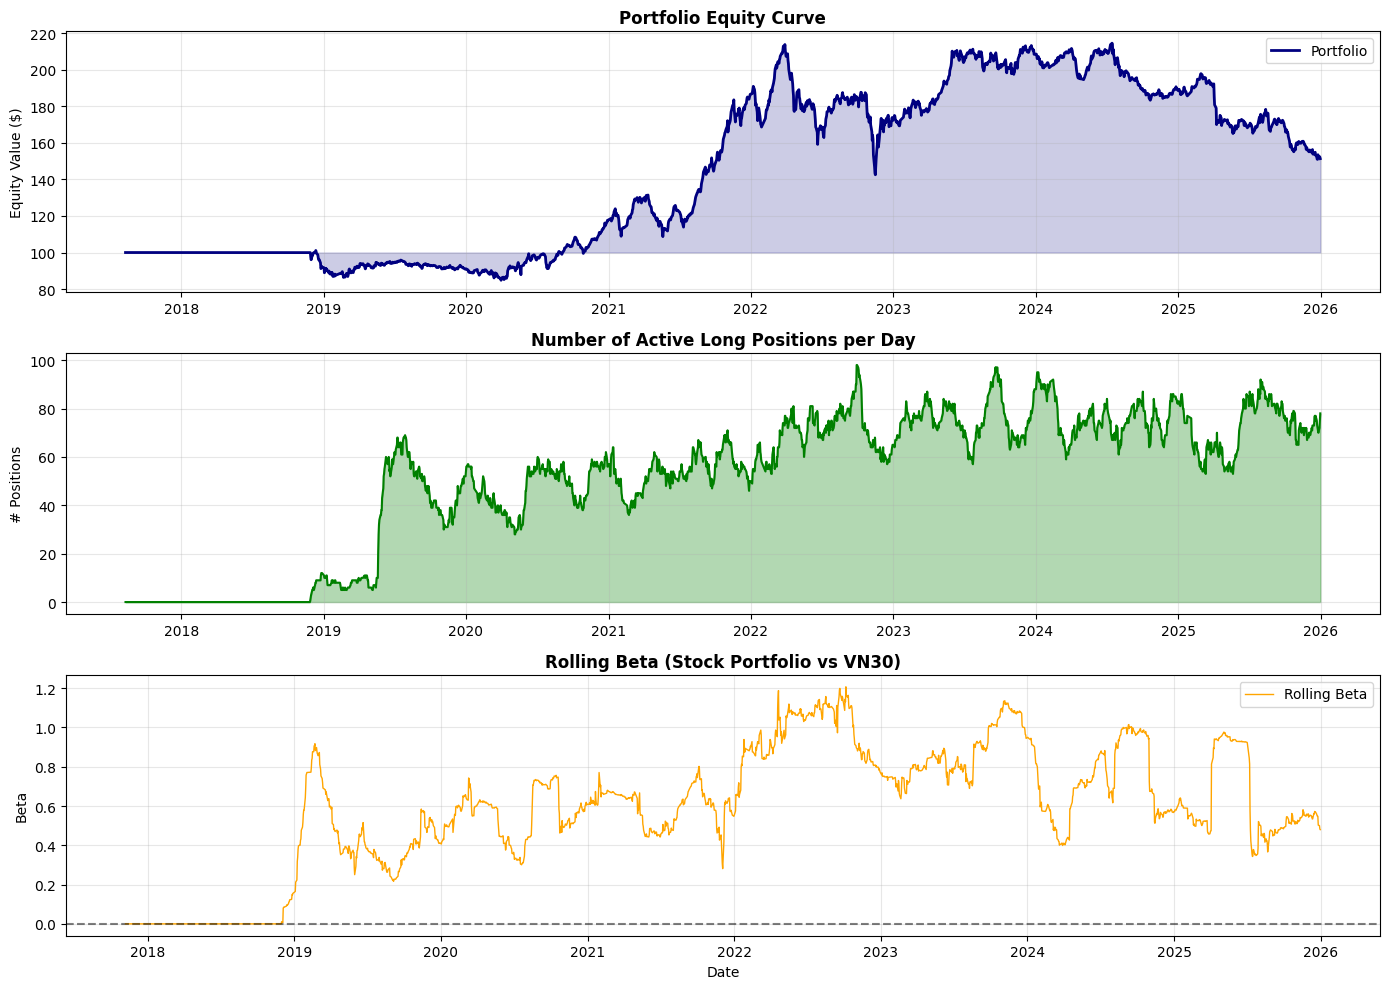

Plots complete.


In [36]:
## Plot equity curve
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Equity curve
ax = axes[0]
ax.plot(equity_curve.index, equity_curve.values, linewidth=2, color='navy', label='Portfolio')
ax.fill_between(equity_curve.index, equity_curve.iloc[0], equity_curve.values, alpha=0.2, color='navy')
ax.set_title('Portfolio Equity Curve', fontsize=12, fontweight='bold')
ax.set_ylabel('Equity Value ($)')
ax.grid(True, alpha=0.3)
ax.legend()

# Active positions over time
ax = axes[1]
ax.plot(active_positions_per_day.index, active_positions_per_day.values, linewidth=1.5, color='green')
ax.fill_between(active_positions_per_day.index, 0, active_positions_per_day.values, alpha=0.3, color='green')
ax.set_title('Number of Active Long Positions per Day', fontsize=12, fontweight='bold')
ax.set_ylabel('# Positions')
ax.grid(True, alpha=0.3)

# Rolling beta
ax = axes[2]
ax.plot(beta_series.index, beta_series.values, linewidth=1, color='orange', label='Rolling Beta')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Rolling Beta (Stock Portfolio vs VN30)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Beta')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print('Plots complete.')

In [37]:
# =========================
# FIX 14: diagnostic report
# =========================
def diagnostic_report(
    weights_df,
    s_df,
    beta_series,
    equity_curve,
    bt_details,
    tradable_mask
):
    active_positions = (weights_df > 0).sum(axis=1)
    daily_ret = equity_curve.pct_change().dropna()

    max_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

    held_and_tradable = (
        (weights_df > 0) &
        tradable_mask.reindex_like(weights_df).fillna(False)
    ).sum(axis=1)

    held_total = (weights_df > 0).sum(axis=1).replace(0, np.nan)
    tradable_fraction = (held_and_tradable / held_total).dropna()

    ann_ret = (equity_curve.iloc[-1] / equity_curve.iloc[0]) ** (252 / max(len(daily_ret), 1)) - 1 if len(daily_ret) > 0 else np.nan
    ann_vol = daily_ret.std() * np.sqrt(252) if len(daily_ret) > 1 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol and ann_vol > 1e-12 else np.nan

    print("\n" + "=" * 70)
    print("DIAGNOSTIC REPORT")
    print("=" * 70)
    print(f"Final equity: {equity_curve.iloc[-1]:.2f}")
    print(f"Total return: {(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100:.2f}%")
    print(f"Annualized return: {ann_ret * 100:.2f}%" if pd.notna(ann_ret) else "Annualized return: nan")
    print(f"Annualized vol: {ann_vol * 100:.2f}%" if pd.notna(ann_vol) else "Annualized vol: nan")
    print(f"Sharpe: {sharpe:.3f}" if pd.notna(sharpe) else "Sharpe: nan")
    print(f"Max drawdown: {max_dd * 100:.2f}%")
    print(f"Avg active positions: {active_positions.mean():.2f}")
    print(f"Median beta: {beta_series.median():.4f}")
    print(f"Avg cost/day: {bt_details['cost'].mean():.4f}")
    print(f"Avg tradable fraction of held positions: {tradable_fraction.mean():.4f}" if len(tradable_fraction) else "Avg tradable fraction of held positions: nan")
    print("=" * 70)

In [38]:
diagnostic_report(
    weights_df=weights_df,
    s_df=sscore_df,
    beta_series=beta_series,
    equity_curve=equity_curve,
    bt_details={'cost': (weights_df.diff().abs().sum(axis=1) + beta_series.diff().abs()) * 0.0005},
    tradable_mask=tradable_mask
)


DIAGNOSTIC REPORT
Final equity: 151.33
Total return: 51.33%
Annualized return: 5.11%
Annualized vol: 14.35%
Sharpe: 0.356
Max drawdown: 33.32%
Avg active positions: 51.10
Median beta: 0.5999
Avg cost/day: 0.0001
Avg tradable fraction of held positions: 1.0000


## Summary: Baseline Pipeline Validation

This notebook implements a complete baseline Vietnam statistical arbitrage strategy:

✅ **Completed Steps:**
1. Data loading: Vietnam stocks + VN30 futures, clean & aligned
2. Universe: Simple liquidity-based selection
3. PCA: Rolling factor extraction without look-ahead bias
4. Residuals: Factor-adjusted returns
5. OU fitting: Mean-reversion speed estimation
6. S-score: Standardized mean-reversion signal
7. Signals: Long-only trading rules (no shorts)
8. Portfolio: Equal-weight construction (no optimization)
9. Hedge: Rolling beta-based VN30 futures short position
10. Backtest: Single clean function, transaction costs included
11. Outputs: Equity curve, Sharpe ratio, diagnostics

**Next Steps for Optimization:**
- Adjust PCA parameters (window, number of factors)
- Tune signal thresholds (s_open, s_close)
- Explore kappa filteri (limit=True with kappa_min)
- Add position sizing optimization
- Improve hedge efficiency
- Reduce transaction costs
- Walk-forward backtesting

**Current Status:** ✓ Conceptually correct, runnable, minimal optimization
**Validation Goal:** Ensure pipeline produces sensible results before parameter tuning

Last 5 trading dates: [Timestamp('2025-12-25 00:00:00'), Timestamp('2025-12-26 00:00:00'), Timestamp('2025-12-29 00:00:00'), Timestamp('2025-12-30 00:00:00'), Timestamp('2025-12-31 00:00:00')]



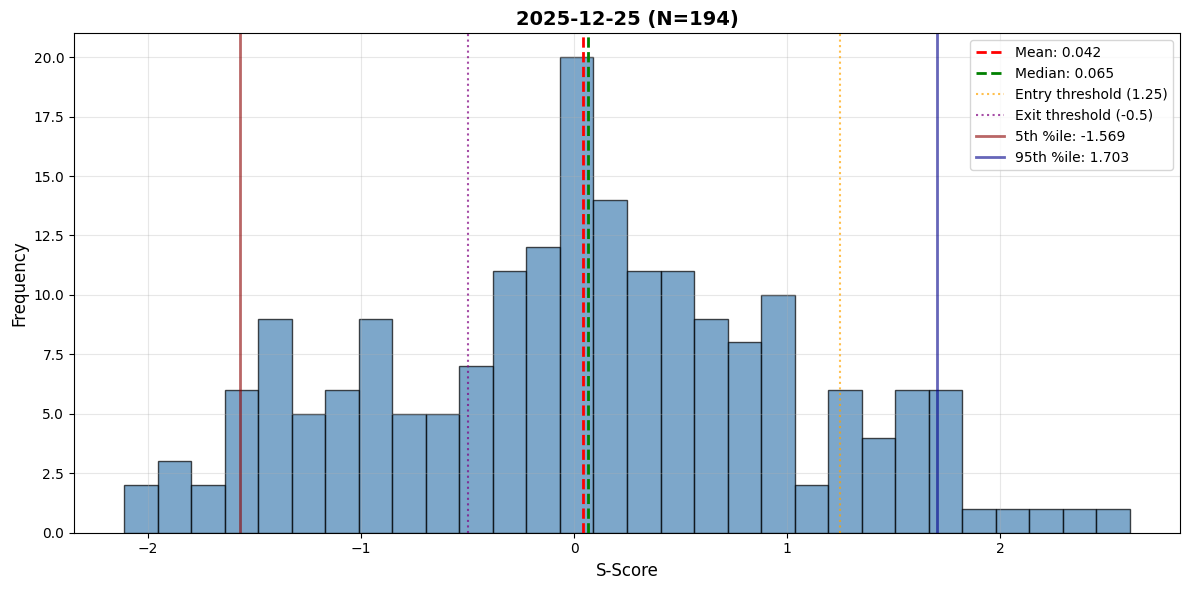

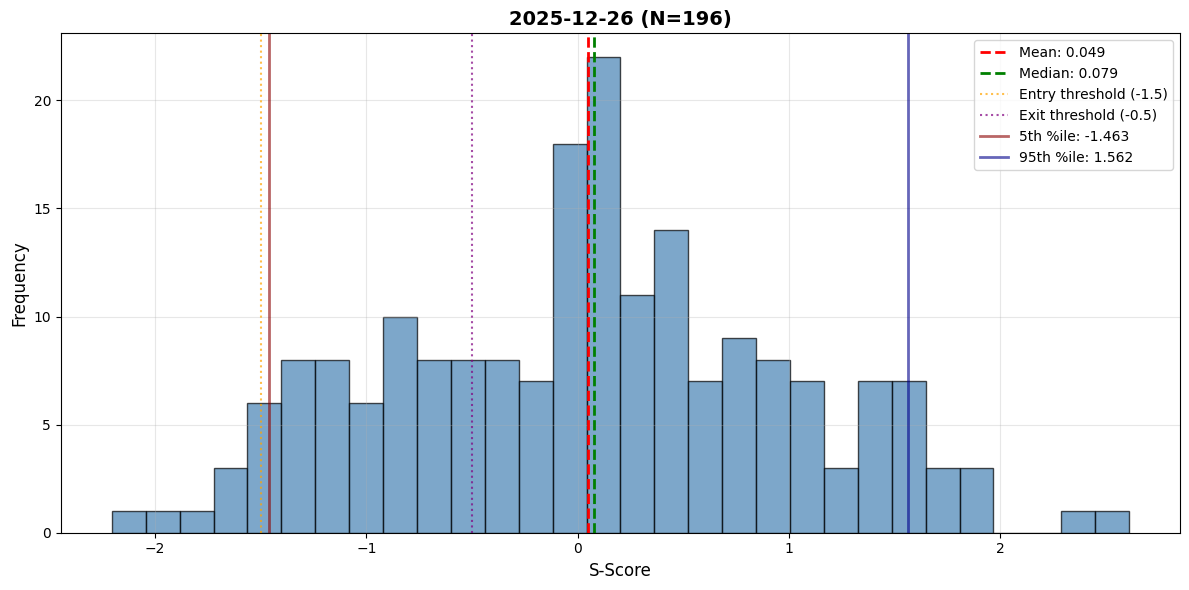

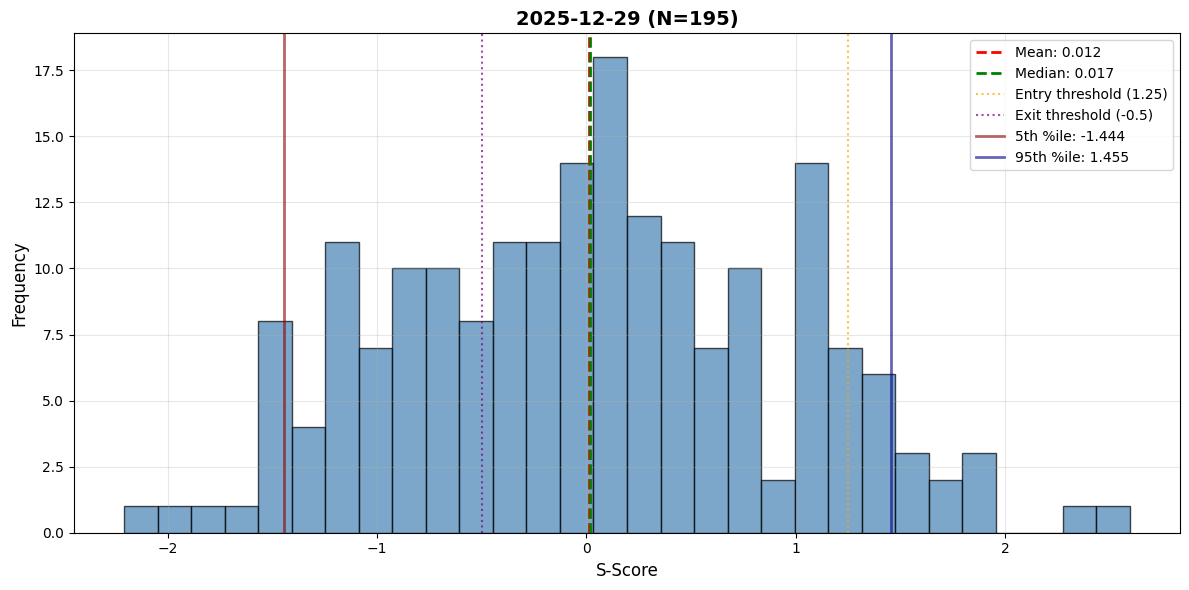

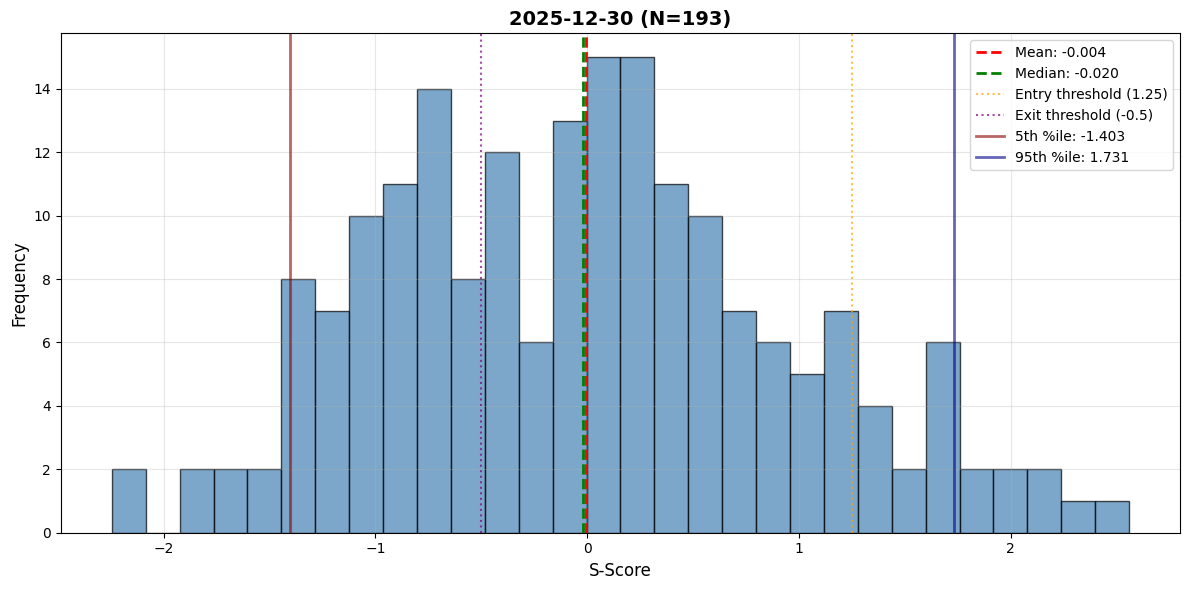

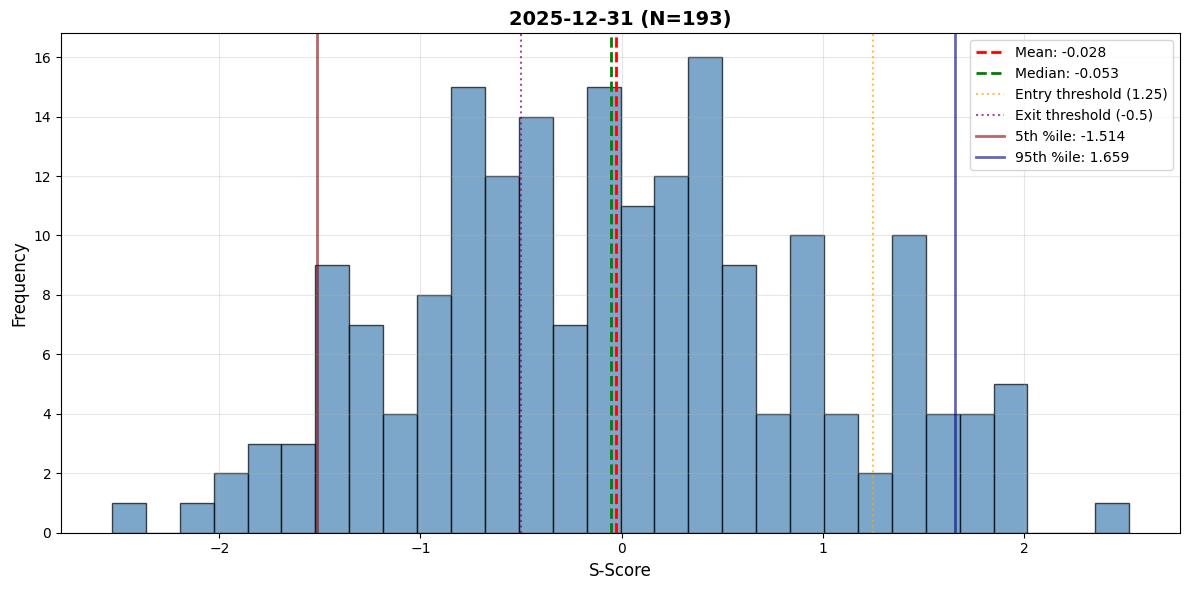


S-Score Distribution Summary (Last 5 Days):

2025-12-25:
  Count: 194
  Mean: 0.0420
  Median: 0.0651
  Std: 0.9852
  Min: -2.1121
  Max: 2.6089
  5th percentile: -1.5692
  95th percentile: 1.7030
  % < -1.5 (buy signal): 6.2%
  % > -0.5 (sell signal): 71.1%

2025-12-26:
  Count: 196
  Mean: 0.0488
  Median: 0.0787
  Std: 0.9383
  Min: -2.2046
  Max: 2.6089
  5th percentile: -1.4625
  95th percentile: 1.5622
  % < -1.5 (buy signal): 4.1%
  % > -0.5 (sell signal): 70.9%

2025-12-29:
  Count: 195
  Mean: 0.0115
  Median: 0.0168
  Std: 0.9170
  Min: -2.2065
  Max: 2.5939
  5th percentile: -1.4441
  95th percentile: 1.4554
  % < -1.5 (buy signal): 4.1%
  % > -0.5 (sell signal): 69.7%

2025-12-30:
  Count: 193
  Mean: -0.0042
  Median: -0.0199
  Std: 0.9658
  Min: -2.2443
  Max: 2.5596
  5th percentile: -1.4031
  95th percentile: 1.7309
  % < -1.5 (buy signal): 3.6%
  % > -0.5 (sell signal): 65.8%

2025-12-31:
  Count: 193
  Mean: -0.0279
  Median: -0.0531
  Std: 0.9832
  Min: -2.5335
  Ma

In [39]:
## Plot S-Score Distribution for Last 5 Days (Individual Plots)
last_5_days = sscore_df.tail(5)
print(f"Last 5 trading dates: {last_5_days.index.tolist()}\n")

# Day 1
date = last_5_days.index[0]
s_values = last_5_days.loc[date].dropna()
p5 = s_values.quantile(0.05)
p95 = s_values.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(s_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(s_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {s_values.mean():.3f}')
ax.axvline(s_values.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {s_values.median():.3f}')
ax.axvline(1.25, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Entry threshold (1.25)')
ax.axvline(-0.5, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label='Exit threshold (-0.5)')
ax.axvline(p5, color='darkred', linestyle='-', linewidth=2, alpha=0.6, label=f'5th %ile: {p5:.3f}')
ax.axvline(p95, color='darkblue', linestyle='-', linewidth=2, alpha=0.6, label=f'95th %ile: {p95:.3f}')
ax.set_title(f'{date.date()} (N={len(s_values)})', fontweight='bold', fontsize=14)
ax.set_xlabel('S-Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Day 2
date = last_5_days.index[1]
s_values = last_5_days.loc[date].dropna()
p5 = s_values.quantile(0.05)
p95 = s_values.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(s_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(s_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {s_values.mean():.3f}')
ax.axvline(s_values.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {s_values.median():.3f}')
ax.axvline(-1.5, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Entry threshold (-1.5)')
ax.axvline(-0.5, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label='Exit threshold (-0.5)')
ax.axvline(p5, color='darkred', linestyle='-', linewidth=2, alpha=0.6, label=f'5th %ile: {p5:.3f}')
ax.axvline(p95, color='darkblue', linestyle='-', linewidth=2, alpha=0.6, label=f'95th %ile: {p95:.3f}')
ax.set_title(f'{date.date()} (N={len(s_values)})', fontweight='bold', fontsize=14)
ax.set_xlabel('S-Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Day 3
date = last_5_days.index[2]
s_values = last_5_days.loc[date].dropna()
p5 = s_values.quantile(0.05)
p95 = s_values.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(s_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(s_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {s_values.mean():.3f}')
ax.axvline(s_values.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {s_values.median():.3f}')
ax.axvline(1.25, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Entry threshold (1.25)')
ax.axvline(-0.5, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label='Exit threshold (-0.5)')
ax.axvline(p5, color='darkred', linestyle='-', linewidth=2, alpha=0.6, label=f'5th %ile: {p5:.3f}')
ax.axvline(p95, color='darkblue', linestyle='-', linewidth=2, alpha=0.6, label=f'95th %ile: {p95:.3f}')
ax.set_title(f'{date.date()} (N={len(s_values)})', fontweight='bold', fontsize=14)
ax.set_xlabel('S-Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Day 4
date = last_5_days.index[3]
s_values = last_5_days.loc[date].dropna()
p5 = s_values.quantile(0.05)
p95 = s_values.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(s_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(s_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {s_values.mean():.3f}')
ax.axvline(s_values.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {s_values.median():.3f}')
ax.axvline(1.25, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Entry threshold (1.25)')
ax.axvline(-0.5, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label='Exit threshold (-0.5)')
ax.axvline(p5, color='darkred', linestyle='-', linewidth=2, alpha=0.6, label=f'5th %ile: {p5:.3f}')
ax.axvline(p95, color='darkblue', linestyle='-', linewidth=2, alpha=0.6, label=f'95th %ile: {p95:.3f}')
ax.set_title(f'{date.date()} (N={len(s_values)})', fontweight='bold', fontsize=14)
ax.set_xlabel('S-Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Day 5
date = last_5_days.index[4]
s_values = last_5_days.loc[date].dropna()
p5 = s_values.quantile(0.05)
p95 = s_values.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(s_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(s_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {s_values.mean():.3f}')
ax.axvline(s_values.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {s_values.median():.3f}')
ax.axvline(1.25, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Entry threshold (1.25)')
ax.axvline(-0.5, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label='Exit threshold (-0.5)')
ax.axvline(p5, color='darkred', linestyle='-', linewidth=2, alpha=0.6, label=f'5th %ile: {p5:.3f}')
ax.axvline(p95, color='darkblue', linestyle='-', linewidth=2, alpha=0.6, label=f'95th %ile: {p95:.3f}')
ax.set_title(f'{date.date()} (N={len(s_values)})', fontweight='bold', fontsize=14)
ax.set_xlabel('S-Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nS-Score Distribution Summary (Last 5 Days):")
print("=" * 70)
for date in last_5_days.index:
    s_values = last_5_days.loc[date].dropna()
    p5 = s_values.quantile(0.05)
    p95 = s_values.quantile(0.95)
    print(f"\n{date.date()}:")
    print(f"  Count: {len(s_values)}")
    print(f"  Mean: {s_values.mean():.4f}")
    print(f"  Median: {s_values.median():.4f}")
    print(f"  Std: {s_values.std():.4f}")
    print(f"  Min: {s_values.min():.4f}")
    print(f"  Max: {s_values.max():.4f}")
    print(f"  5th percentile: {p5:.4f}")
    print(f"  95th percentile: {p95:.4f}")
    print(f"  % < -1.5 (buy signal): {(s_values < -1.5).sum() / len(s_values) * 100:.1f}%")
    print(f"  % > -0.5 (sell signal): {(s_values > -0.5).sum() / len(s_values) * 100:.1f}%")